In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import pandas as pd
import geopandas as gpd
import contextily as ctx
import numpy as np
import os
import time
from geopy.geocoders import Nominatim
from shapely.geometry import Point
from matplotlib.offsetbox import AnnotationBbox, OffsetImage

# Carregando o banco de dados da Papaiz

In [2]:
import sys  
sys.path.insert(0, '/home/ubuntu/Jack/papiron-classificacao/dist')
from replica_banco import *

        cd_exame  dentes_carie  dentes_ausentes    sg_sexo  idade  \
0     alp.025918             2                0   feminino   24.0   
1     alp.026080            12                0  masculino   24.0   
2     alp.026233             6                0  masculino   27.0   
3     alp.026520             5               10   feminino   63.0   
4     alp.026854             2                0  masculino   22.0   
...          ...           ...              ...        ...    ...   
2992  vma.247707             2                0  masculino   26.0   
2993  vma.247871             6                4  masculino   63.0   
2994  vma.247939             6               11  masculino   71.0   
2995  vma.248033             0                3   feminino   48.0   
2996  vma.248045             4                2  masculino   55.0   

      coroa unitaria sobre dente  coroa unitaria sobre implante  \
0                              0                              0   
1                              0     


# Tabelas do banco de dados

| Schema  | Name                 | Type  | Owner    | Variables |
|---------|----------------------|-------|---------|--------|
| public  | **alteracao_anatomica**  | table | machiron | cd_exame                                          alteracao  grupo |
| public  | **alteracao_dental**     | table | machiron | bla |
| public  | analisados_auditoria | table | machiron | cd_exame dentes_restauracao |
| public  | auditoria            | table | machiron | alteracao    cd_exame |
| public  | ausentes_clean       | table | machiron | cd_exame  nr_dente      alteracao  grupo |
| public  | calcificacao         | table | machiron | cd_exame  calcificacao  dentes_ausentes    sg_sexo  idade  alteracao  se_panoramica|
| public  | cpod_annotations     | table | machiron | cd_exame dentes_carie dentes_ausentes sg_sexo idade coroa unitaria sobre dente coroa unitaria sobre implante retentor intraradicular supranumerario restauracao metalica restauracao nao metalica protese fixa sobre implante protese fixa sobre dente condutos obturados raiz residual implante protocolo contencao aparelho ortodondico placa carie|
| public  | **exame**                | table | machiron | id_exame    dt_exame    sg_sexo dt_nascimento    cd_exame |
| public  | hiperpneumatizacao   | table | machiron | cd_exame hiperpneumatizacao  dentes_ausentes    sg_sexo  idade alteracao|
| public  | info_cpod            | table | machiron | cd_exame  dentes_carie  dentes_ausentes    sg_sexo  idade alteracao  se_panoramica|
| public  | info_cpod_cvat_n400  | table | machiron | cd_exame  dentes_carie  dentes_ausentes  dentes_restauracao dentes_protese  dentes_coroa_unitaria    sg_sexo  idade alteracao  se_panoramica|
| public  | informacoes_laudo    | table | machiron | cd_exame    dt_exame    sg_sexo dt_nascimento |
| public  | infos_filtro         | table | machiron | cd_exame  dentes_ausentes    sg_sexo            alteracao  idade  se_panoramica  |
| public  | **lista_alteracoes**     | table | machiron | alteracao  grupo       tipo nome_grupo|


In [3]:
tabela = ReplicaBanco('view_imagem_radiolucida_na_coroa__solucao_de_continuidade_na_co')
tabela.tabela
infos = tabela.df
print(infos.head())
print(infos.shape)

     cd_exame
0  alp.025854
1  alp.025874
2  alp.025876
3  alp.025878
4  alp.025882
(400, 1)


# Informações do laudo

In [4]:
tabela = ReplicaBanco('vw_exame_se_pan')
tabela.tabela
infos = tabela.df
print(infos.head())
print(infos.shape)

   id_exame    dt_exame    sg_sexo dt_nascimento    cd_exame  se_panoramica
0      5455  2020-01-02   feminino    1990-10-15  alp.025854            1.0
1      5458  2020-01-02  masculino    2014-01-25  alp.025857            0.0
2       443  2020-01-03   feminino    1948-10-23  alp.025868            1.0
3       444  2020-01-04   feminino    1962-08-11  alp.025874            1.0
4       523  2020-01-04   feminino    1956-07-17  alp.025876            1.0
(217857, 6)


Filtrar somente os que possuem panoramica

In [5]:
infos_pan = infos[infos.se_panoramica==1]
infos_pan.shape

(207875, 6)

Calcular idade

In [6]:
# Garantir que as colunas estão em formato datetime
infos_pan['dt_exame'] = pd.to_datetime(infos_pan['dt_exame'], errors='coerce')
infos_pan['dt_nascimento'] = pd.to_datetime(infos_pan['dt_nascimento'], errors='coerce')

# Calcular a idade em anos no momento do exame
infos_pan['idade'] = infos_pan['dt_exame'].sub(infos_pan['dt_nascimento']).dt.days // 365
infos_pan

<ipython-input-6-45f84f61ab15>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  infos_pan['dt_exame'] = pd.to_datetime(infos_pan['dt_exame'], errors='coerce')
<ipython-input-6-45f84f61ab15>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  infos_pan['dt_nascimento'] = pd.to_datetime(infos_pan['dt_nascimento'], errors='coerce')
<ipython-input-6-45f84f61ab15>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

S

,id_exame,dt_exame,sg_sexo,dt_nascimento,cd_exame,se_panoramica,idade
0,5455,2020-01-02,feminino,1990-10-15,alp.025854,1.0,29.0
2,443,2020-01-03,feminino,1948-10-23,alp.025868,1.0,71.0
3,444,2020-01-04,feminino,1962-08-11,alp.025874,1.0,57.0
4,523,2020-01-04,feminino,1956-07-17,alp.025876,1.0,63.0
5,450,2020-01-04,feminino,1988-06-27,alp.025878,1.0,31.0
...,...,...,...,...,...,...,...
217851,121787,2020-12-30,feminino,1970-12-04,vma.248133,1.0,50.0
217852,122108,2020-12-30,feminino,1978-12-26,vma.248138,1.0,42.0
217853,122709,2020-12-30,feminino,1932-08-22,vma.248140,1.0,88.0
217854,135564,2020-12-30,masculino,1985-10-20,vma.248141,1.0,35.0


In [7]:
infos_pan.describe()

,id_exame,dt_exame,dt_nascimento,se_panoramica,idade
count,207875.000000,207875,207866,207875.0,207866.000000
mean,120014.974581,2020-02-01 23:04:37.834275584,1982-12-18 15:22:31.182011456,1.0,36.650116
min,443.000000,2019-01-02 00:00:00,1791-11-20 00:00:00,1.0,-178.000000
25%,66563.500000,2019-07-31 00:00:00,1969-02-19 00:00:00,1.0,22.000000
50%,121251.000000,2020-02-07 00:00:00,1984-01-12 00:00:00,1.0,36.000000
75%,175124.500000,2020-08-20 00:00:00,1997-11-26 00:00:00,1.0,51.000000
max,230781.000000,2020-12-30 00:00:00,2197-05-14 00:00:00,1.0,228.000000
std,63749.953361,NaN,NaN,0.0,19.073016


In [8]:
infos_pan.loc[infos_pan['idade'] < 0, 'idade'] = np.nan
infos_pan.describe()

,id_exame,dt_exame,dt_nascimento,se_panoramica,idade
count,207875.000000,207875,207866,207875.0,207863.000000
mean,120014.974581,2020-02-01 23:04:37.834275584,1982-12-18 15:22:31.182011456,1.0,36.651511
min,443.000000,2019-01-02 00:00:00,1791-11-20 00:00:00,1.0,0.000000
25%,66563.500000,2019-07-31 00:00:00,1969-02-19 00:00:00,1.0,22.000000
50%,121251.000000,2020-02-07 00:00:00,1984-01-12 00:00:00,1.0,36.000000
75%,175124.500000,2020-08-20 00:00:00,1997-11-26 00:00:00,1.0,51.000000
max,230781.000000,2020-12-30 00:00:00,2197-05-14 00:00:00,1.0,228.000000
std,63749.953361,NaN,NaN,0.0,19.066984


Criando a variável faixa etária

In [9]:
# Categorias de idade personalizadas
bins = [-1, 4, 5, 11, 12, 14, 19, 34, 44, 64, 74, float('inf')]
labels = [
    '0-4',
    '5',
    '6-11',
    '12',
    '13-14',
    '15-19',
    '20-34',
    '35-44',
    '45-64',
    '65-74',
    '75+'
]

# Criar a nova variável
infos_pan['grupo_etario'] = pd.cut(infos_pan['idade'], bins=bins, labels=labels, right=True, include_lowest=True)

<ipython-input-9-656ac7b94b07>:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  infos_pan['grupo_etario'] = pd.cut(infos_pan['idade'], bins=bins, labels=labels, right=True, include_lowest=True)


In [10]:
infos_pan.head()

,id_exame,dt_exame,sg_sexo,dt_nascimento,cd_exame,se_panoramica,idade,grupo_etario
0,5455,2020-01-02,feminino,1990-10-15,alp.025854,1.0,29.0,20-34
2,443,2020-01-03,feminino,1948-10-23,alp.025868,1.0,71.0,65-74
3,444,2020-01-04,feminino,1962-08-11,alp.025874,1.0,57.0,45-64
4,523,2020-01-04,feminino,1956-07-17,alp.025876,1.0,63.0,45-64
5,450,2020-01-04,feminino,1988-06-27,alp.025878,1.0,31.0,20-34


In [11]:
faixas = pd.DataFrame(infos_pan['grupo_etario'].value_counts().sort_index())
print(faixas)

              count
grupo_etario       
0-4            1086
5              1701
6-11          19900
12             3044
13-14          5376
15-19         13840
20-34         54678
35-44         38279
45-64         51905
65-74         12519
75+            5535


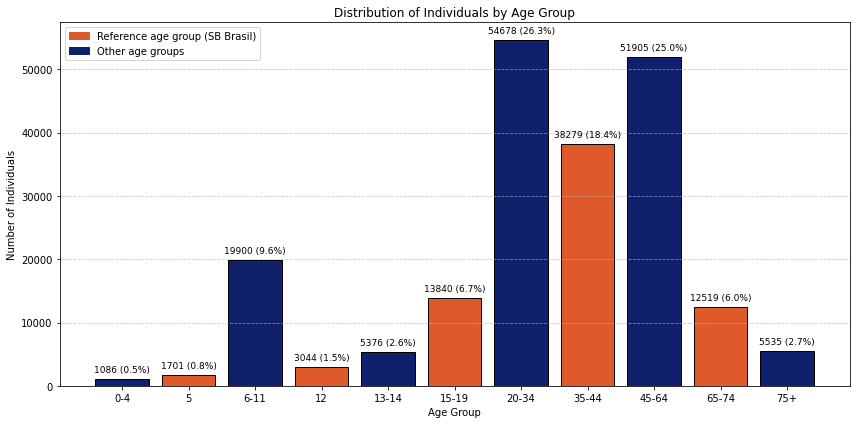

In [12]:
# Resetar índice para facilitar a manipulação
faixas_reset = faixas.reset_index()

# Calcular frequência relativa (%)
total = faixas_reset['count'].sum()
faixas_reset['percentual'] = (faixas_reset['count'] / total * 100).round(1)

# Faixas de referência (para destacar em laranja vibrante)
faixas_referencia = ['5', '12', '15-19', '35-44', '65-74']

# Definir cores personalizadas
cores = ['#E0592A' if faixa in faixas_referencia else '#0F206C' for faixa in faixas_reset['grupo_etario']]

# Criar gráfico
plt.figure(figsize=(12, 6))
plt.bar(faixas_reset['grupo_etario'], faixas_reset['count'], color=cores, edgecolor='black')

# Títulos e rótulos
plt.xlabel('Age Group')
plt.ylabel('Number of Individuals')
plt.title('Distribution of Individuals by Age Group')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibir valores absolutos e relativos sobre as barras
for i, row in faixas_reset.iterrows():
    plt.text(i, row['count'] + total*0.005, 
             f"{row['count']} ({row['percentual']}%)", 
             ha='center', fontsize=9, color='black')

# Legenda no canto superior esquerdo
referencia_patch = mpatches.Patch(color='#E0592A', label='Reference age group (SB Brasil)')
outras_patch = mpatches.Patch(color='#0F206C', label='Other age groups')
plt.legend(handles=[referencia_patch, outras_patch], loc='upper left')

plt.tight_layout()

# Salvar o gráfico
output_path = '/home/ubuntu/Jack/papiron-classificacao/imagens'
plt.savefig(os.path.join(output_path, 'distribuicao_grupo_etario_cores_personalizadas.png'), dpi=300, bbox_inches='tight')

# Mostrar no notebook
plt.show()


Criando a variável de origem 

In [13]:
infos_pan['origem'] = infos_pan['cd_exame'].str[:3]
infos_pan

<ipython-input-13-b8a90ff9320e>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  infos_pan['origem'] = infos_pan['cd_exame'].str[:3]


,id_exame,dt_exame,sg_sexo,dt_nascimento,cd_exame,se_panoramica,idade,grupo_etario,origem
0,5455,2020-01-02,feminino,1990-10-15,alp.025854,1.0,29.0,20-34,alp
2,443,2020-01-03,feminino,1948-10-23,alp.025868,1.0,71.0,65-74,alp
3,444,2020-01-04,feminino,1962-08-11,alp.025874,1.0,57.0,45-64,alp
4,523,2020-01-04,feminino,1956-07-17,alp.025876,1.0,63.0,45-64,alp
5,450,2020-01-04,feminino,1988-06-27,alp.025878,1.0,31.0,20-34,alp
...,...,...,...,...,...,...,...,...,...
217851,121787,2020-12-30,feminino,1970-12-04,vma.248133,1.0,50.0,45-64,vma
217852,122108,2020-12-30,feminino,1978-12-26,vma.248138,1.0,42.0,35-44,vma
217853,122709,2020-12-30,feminino,1932-08-22,vma.248140,1.0,88.0,75+,vma
217854,135564,2020-12-30,masculino,1985-10-20,vma.248141,1.0,35.0,35-44,vma


In [14]:
# Dicionário de mapeamento
mapeamento = {
    'alp': 'Alphaville',
    'jar': 'Jardins',
    'tat': 'Tatuape',
    'lap': 'Lapa',
    'bra': 'Jd. America',
    'ibr': 'Ibirapuera',
    'ipi': 'Ipiranga',
    'moo': 'Mooca',
    'mrb': 'Morumbi',
    'osa': 'Osasco',
    'pen': 'Penha',
    'san': 'Santana',
    'sto': 'Santo Amaro',
    'tuc': 'Tucuruvi',
    'vma': 'Vila Mariana'
}

infos_pan['origem'] = infos_pan['origem'].replace(mapeamento)
infos_pan

<ipython-input-14-e9938bb8858a>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  infos_pan['origem'] = infos_pan['origem'].replace(mapeamento)


,id_exame,dt_exame,sg_sexo,dt_nascimento,cd_exame,se_panoramica,idade,grupo_etario,origem
0,5455,2020-01-02,feminino,1990-10-15,alp.025854,1.0,29.0,20-34,Alphaville
2,443,2020-01-03,feminino,1948-10-23,alp.025868,1.0,71.0,65-74,Alphaville
3,444,2020-01-04,feminino,1962-08-11,alp.025874,1.0,57.0,45-64,Alphaville
4,523,2020-01-04,feminino,1956-07-17,alp.025876,1.0,63.0,45-64,Alphaville
5,450,2020-01-04,feminino,1988-06-27,alp.025878,1.0,31.0,20-34,Alphaville
...,...,...,...,...,...,...,...,...,...
217851,121787,2020-12-30,feminino,1970-12-04,vma.248133,1.0,50.0,45-64,Vila Mariana
217852,122108,2020-12-30,feminino,1978-12-26,vma.248138,1.0,42.0,35-44,Vila Mariana
217853,122709,2020-12-30,feminino,1932-08-22,vma.248140,1.0,88.0,75+,Vila Mariana
217854,135564,2020-12-30,masculino,1985-10-20,vma.248141,1.0,35.0,35-44,Vila Mariana


# Identificar tipo de dentição

In [15]:
tabela = ReplicaBanco('alteracao_anatomica')
tabela.tabela
alt_anat = tabela.df
print(alt_anat.head())
print(alt_anat.shape)

     cd_exame                                          alteracao  grupo
0  alp.025868                                     denticao mista    2.0
1  alp.025874                                denticao permanente    3.0
2  alp.025874  calcificacao do ligamento estilo hioideo direi...    8.0
3  alp.025891                                denticao permanente    3.0
4  alp.025891               fenomeno de retencao de muco direito    5.0
(1298354, 3)


In [16]:
# Filtrar linhas onde 'alteracao' contém a palavra 'denticao'
filtro_denticao = alt_anat[alt_anat['alteracao'].str.contains('denticao', case=False, na=False)]
filtro_denticao

,cd_exame,alteracao,grupo
0,alp.025868,denticao mista,2.0
1,alp.025874,denticao permanente,3.0
3,alp.025891,denticao permanente,3.0
5,alp.025892,denticao permanente,3.0
8,alp.025887,denticao permanente,3.0
...,...,...,...
1298337,vma.236197,denticao mista,2.0
1298338,vma.236201,denticao permanente,3.0
1298343,sto.241707,denticao permanente,3.0
1298347,vma.220126,denticao permanente,3.0


In [17]:
filtro_denticao.alteracao.value_counts()

alteracao
denticao permanente    389122
denticao mista          44684
sem denticao             1550
denticao decidua          362
Name: count, dtype: int64

In [18]:
filtro_denticao = filtro_denticao.rename(columns={'alteracao': 'denticao'})
filtro_denticao

,cd_exame,denticao,grupo
0,alp.025868,denticao mista,2.0
1,alp.025874,denticao permanente,3.0
3,alp.025891,denticao permanente,3.0
5,alp.025892,denticao permanente,3.0
8,alp.025887,denticao permanente,3.0
...,...,...,...
1298337,vma.236197,denticao mista,2.0
1298338,vma.236201,denticao permanente,3.0
1298343,sto.241707,denticao permanente,3.0
1298347,vma.220126,denticao permanente,3.0


In [19]:
filtro_denticao=filtro_denticao.drop_duplicates()
filtro_denticao

,cd_exame,denticao,grupo
0,alp.025868,denticao mista,2.0
1,alp.025874,denticao permanente,3.0
3,alp.025891,denticao permanente,3.0
5,alp.025892,denticao permanente,3.0
8,alp.025887,denticao permanente,3.0
...,...,...,...
649160,vma.236197,denticao mista,2.0
649161,vma.236201,denticao permanente,3.0
649166,sto.241707,denticao permanente,3.0
649170,vma.220126,denticao permanente,3.0


In [20]:
filtro_denticao = filtro_denticao.drop(columns=['grupo'])
filtro_denticao

,cd_exame,denticao
0,alp.025868,denticao mista
1,alp.025874,denticao permanente
3,alp.025891,denticao permanente
5,alp.025892,denticao permanente
8,alp.025887,denticao permanente
...,...,...
649160,vma.236197,denticao mista
649161,vma.236201,denticao permanente
649166,sto.241707,denticao permanente
649170,vma.220126,denticao permanente


In [21]:
# Adicionando a variavel tipo de denticao
infos_pan = pd.merge(infos_pan,filtro_denticao,on="cd_exame",how="left")
infos_pan

,id_exame,dt_exame,sg_sexo,dt_nascimento,cd_exame,se_panoramica,idade,grupo_etario,origem,denticao
0,5455,2020-01-02,feminino,1990-10-15,alp.025854,1.0,29.0,20-34,Alphaville,denticao permanente
1,443,2020-01-03,feminino,1948-10-23,alp.025868,1.0,71.0,65-74,Alphaville,denticao mista
2,444,2020-01-04,feminino,1962-08-11,alp.025874,1.0,57.0,45-64,Alphaville,denticao permanente
3,523,2020-01-04,feminino,1956-07-17,alp.025876,1.0,63.0,45-64,Alphaville,denticao permanente
4,450,2020-01-04,feminino,1988-06-27,alp.025878,1.0,31.0,20-34,Alphaville,denticao permanente
...,...,...,...,...,...,...,...,...,...,...
207870,121787,2020-12-30,feminino,1970-12-04,vma.248133,1.0,50.0,45-64,Vila Mariana,denticao permanente
207871,122108,2020-12-30,feminino,1978-12-26,vma.248138,1.0,42.0,35-44,Vila Mariana,denticao permanente
207872,122709,2020-12-30,feminino,1932-08-22,vma.248140,1.0,88.0,75+,Vila Mariana,denticao permanente
207873,135564,2020-12-30,masculino,1985-10-20,vma.248141,1.0,35.0,35-44,Vila Mariana,denticao permanente


Avaliar em relação ao tipo de denticao

In [22]:
infos_pan.denticao.value_counts()

denticao
denticao permanente    186328
denticao mista          21371
denticao decidua          176
Name: count, dtype: int64

In [23]:
tabela_denticao = infos_pan['denticao'].value_counts(normalize=True) * 100
tabela_denticao

denticao
denticao permanente    89.634636
denticao mista         10.280698
denticao decidua        0.084666
Name: proportion, dtype: float64

In [24]:
# Criar a tabela com valores relativos
tabela_denticao = infos_pan['denticao'].value_counts(normalize=True) * 100
tabela_denticao = tabela_denticao.reset_index()
tabela_denticao.columns = ['Type of Dentition', 'Percentage (%)']
tabela_denticao['Percentage (%)'] = tabela_denticao['Percentage (%)'].round(2)

# Gerar LaTeX e substituir por \hline
latex_body = tabela_denticao.to_latex(index=False)
latex_body = (
    latex_body.replace(r'\toprule', r'\hline')
              .replace(r'\midrule', r'\hline')
              .replace(r'\bottomrule', r'\hline')
)

# Adicionar estrutura de ambiente table com caption e label
latex_full = (
    r'\begin{table}[H]' + '\n'
    r'\centering' + '\n'
    r'\caption{Distribution of Dentition Types}' + '\n'
    r'\label{tab:denticao}' + '\n' +
    latex_body +
    r'\end{table}'
)

# Exibir a tabela final
print(latex_full)


\begin{table}[H]
\centering
\caption{Distribution of Dentition Types}
\label{tab:denticao}
\begin{tabular}{lr}
\hline
Type of Dentition & Percentage (%) \\
\hline
denticao permanente & 89.630000 \\
denticao mista & 10.280000 \\
denticao decidua & 0.080000 \\
\hline
\end{tabular}
\end{table}


# Identificar dentes ausentes e cáries

In [25]:
tabela = ReplicaBanco('vw_exame_caries_ausentes')
tabela.tabela
alt_dent = tabela.df
print(alt_dent.head())
print(alt_dent.shape)

     cd_exame  total_caries  total_dentes_ausentes
0  alp.025854            12                      8
1  alp.025857             0                      4
2  alp.025868             0                     10
3  alp.025874             4                     30
4  alp.025876             8                     12
(213689, 3)


Identificar a quantidade de dentes ausentes

In [26]:
infos_pan = pd.merge(infos_pan,alt_dent,on="cd_exame",how="left")
infos_pan

,id_exame,dt_exame,sg_sexo,dt_nascimento,cd_exame,se_panoramica,idade,grupo_etario,origem,denticao,total_caries,total_dentes_ausentes
0,5455,2020-01-02,feminino,1990-10-15,alp.025854,1.0,29.0,20-34,Alphaville,denticao permanente,12.0,8.0
1,443,2020-01-03,feminino,1948-10-23,alp.025868,1.0,71.0,65-74,Alphaville,denticao mista,0.0,10.0
2,444,2020-01-04,feminino,1962-08-11,alp.025874,1.0,57.0,45-64,Alphaville,denticao permanente,4.0,30.0
3,523,2020-01-04,feminino,1956-07-17,alp.025876,1.0,63.0,45-64,Alphaville,denticao permanente,8.0,12.0
4,450,2020-01-04,feminino,1988-06-27,alp.025878,1.0,31.0,20-34,Alphaville,denticao permanente,6.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...
207870,121787,2020-12-30,feminino,1970-12-04,vma.248133,1.0,50.0,45-64,Vila Mariana,denticao permanente,24.0,8.0
207871,122108,2020-12-30,feminino,1978-12-26,vma.248138,1.0,42.0,35-44,Vila Mariana,denticao permanente,0.0,2.0
207872,122709,2020-12-30,feminino,1932-08-22,vma.248140,1.0,88.0,75+,Vila Mariana,denticao permanente,0.0,64.0
207873,135564,2020-12-30,masculino,1985-10-20,vma.248141,1.0,35.0,35-44,Vila Mariana,denticao permanente,0.0,14.0


In [27]:
tabela_origem = infos_pan[['origem']].value_counts(normalize=True)*100
tabela_origem

origem      
Santana         16.276609
Tatuape         14.532772
Santo Amaro     13.965604
Jardins          9.871317
Vila Mariana     9.388815
Jd. America      7.874925
Lapa             6.753578
Mooca            3.562718
Penha            3.436681
Ibirapuera       3.411666
Osasco           2.894528
Alphaville       2.856043
Ipiranga         2.818521
Morumbi          2.336981
Tucuruvi         0.019242
Name: proportion, dtype: float64

In [28]:
tabela_origem.sum()

100.0

In [29]:
# Frequência absoluta
freq_abs = infos_pan['origem'].value_counts()

# Frequência relativa (%)
freq_rel = infos_pan['origem'].value_counts(normalize=True) * 100

# Combinar em um DataFrame
tabela_origem = pd.DataFrame({
    'Clinic': freq_abs.index,
    'Absolute Frequency': freq_abs.values,
    'Relative Frequency (%)': freq_rel.values.round(2)
})

tabela_origem['Relative Frequency (%)'] = tabela_origem['Relative Frequency (%)'].map(lambda x: f'{x:.2f}')

# Adicionar linha de total
total_abs = tabela_origem['Absolute Frequency'].sum()
tabela_origem.loc[len(tabela_origem.index)] = ['Total', total_abs, '100.00']

# Gerar LaTeX
latex_code = tabela_origem.to_latex(index=False)

# Substituir as regras booktabs por \hline
latex_code = (
    latex_code.replace(r'\toprule', r'\hline')
              .replace(r'\midrule', r'\hline')
              .replace(r'\bottomrule', r'\hline')
)

# Adicionar ambiente table
latex_final = (
    r'\begin{table}[H]' + '\n'
    r'\centering' + '\n'
    r'\caption{Distribution of Exams by Clinic}' + '\n'
    r'\label{tab:origem}' + '\n' +
    latex_code +
    r'\end{table}'
)

# Exibir LaTeX final
print(latex_final)


\begin{table}[H]
\centering
\caption{Distribution of Exams by Clinic}
\label{tab:origem}
\begin{tabular}{lrl}
\hline
Clinic & Absolute Frequency & Relative Frequency (%) \\
\hline
Santana & 33835 & 16.28 \\
Tatuape & 30210 & 14.53 \\
Santo Amaro & 29031 & 13.97 \\
Jardins & 20520 & 9.87 \\
Vila Mariana & 19517 & 9.39 \\
Jd. America & 16370 & 7.87 \\
Lapa & 14039 & 6.75 \\
Mooca & 7406 & 3.56 \\
Penha & 7144 & 3.44 \\
Ibirapuera & 7092 & 3.41 \\
Osasco & 6017 & 2.89 \\
Alphaville & 5937 & 2.86 \\
Ipiranga & 5859 & 2.82 \\
Morumbi & 4858 & 2.34 \\
Tucuruvi & 40 & 0.02 \\
Total & 207875 & 100.00 \\
\hline
\end{tabular}
\end{table}


In [30]:
tabela_origem

,Clinic,Absolute Frequency,Relative Frequency (%)
0,Santana,33835,16.28
1,Tatuape,30210,14.53
2,Santo Amaro,29031,13.97
3,Jardins,20520,9.87
4,Vila Mariana,19517,9.39
5,Jd. America,16370,7.87
6,Lapa,14039,6.75
7,Mooca,7406,3.56
8,Penha,7144,3.44
9,Ibirapuera,7092,3.41


In [31]:
tabela_origem["Relative Frequency (%)"]

0      16.28
1      14.53
2      13.97
3       9.87
4       9.39
5       7.87
6       6.75
7       3.56
8       3.44
9       3.41
10      2.89
11      2.86
12      2.82
13      2.34
14      0.02
15    100.00
Name: Relative Frequency (%), dtype: object

In [32]:
# Caminho do arquivo
caminho = 'coordenadas_bairros.csv'

# Carregar o CSV em um DataFrame
df_coords = pd.read_csv(caminho)

# Correção manual no DataFrame de coordenadas

# Jardins → coordenadas de Cerqueira César
df_coords.loc[df_coords['bairro'] == 'Jardins', 'lat'] = -23.561575
df_coords.loc[df_coords['bairro'] == 'Jardins', 'lon'] = -46.660982

# Jd. America → coordenadas corretas de Jardim América (bairro de São Paulo)
df_coords.loc[df_coords['bairro'] == 'Jd. America', 'lat'] = -23.570323
df_coords.loc[df_coords['bairro'] == 'Jd. America', 'lon'] = -46.679811

df_coords

,bairro,lat,lon
0,Alphaville,-23.498981,-46.847832
1,Ibirapuera,-23.581731,-46.660043
2,Ipiranga,-23.589273,-46.606162
3,Jardins,-23.561575,-46.660982
4,Jd. America,-23.570323,-46.679811
5,Lapa,-23.521576,-46.704349
6,Mooca,-23.560681,-46.597192
7,Morumbi,-23.596499,-46.717845
8,Osasco,-23.532486,-46.791680
9,Penha,-23.533495,-46.542669


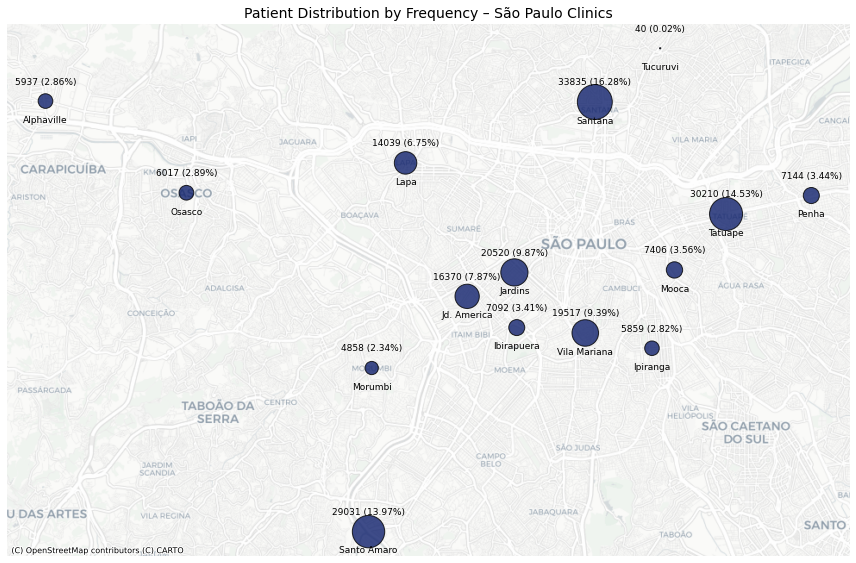

In [33]:
# Caminho de saída
output_path = '/home/ubuntu/Jack/papiron-classificacao/imagens'
os.makedirs(output_path, exist_ok=True)

# Renomear coluna para garantir consistência
df_coords = df_coords.rename(columns={'bairro': 'origem'})
tabela_origem = tabela_origem.rename(columns={'Clinic': 'origem'})

# Mesclar as tabelas df_coords e tabela_origem com base na coluna 'origem'
df = df_coords.merge(tabela_origem, on='origem')

# Garantir que a coluna 'Relative Frequency (%)' seja numérica
df['Relative Frequency (%)'] = pd.to_numeric(df['Relative Frequency (%)'], errors='coerce')

# Criar GeoDataFrame com coordenadas
geometry = [Point(xy) for xy in zip(df['lon'], df['lat'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

# Reprojetar para Web Mercator (necessário para contextily)
gdf = gdf.to_crs(epsg=3857)

# Plotar o mapa
fig, ax = plt.subplots(figsize=(12, 12))

# Usar a frequência relativa para o tamanho das bolhas
gdf.plot(ax=ax,
         markersize=gdf["Relative Frequency (%)"] * 75,  # Ajuste visual do tamanho das bolhas
         color='#0F206C', edgecolor='black', alpha=0.8)

# Adicionar o mapa base
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# Título e ajustes no layout
ax.set_title('Patient Distribution by Frequency – São Paulo Clinics', fontsize=14)
ax.axis('off')
plt.tight_layout()

# Adicionar valores e nomes
for i, row in gdf.iterrows():
    # Colocando o valor absoluto acima da bolha
    ax.text(row.geometry.x, row.geometry.y + 850, f"{row['Absolute Frequency']} ({row['Relative Frequency (%)']}%)" , fontsize=9, ha='center', va='center', color='black')
    
    # Colocando a frequência relativa entre parênteses
    # ax.text(row.geometry.x, row.geometry.y + 250, f"({row['Relative Frequency (%)']}%)", fontsize=9, ha='center', va='center', color='black')
    
    # Colocando o nome do bairro abaixo da bolha
    ax.text(row.geometry.x, row.geometry.y - 850, row['origem'], fontsize=9, ha='center', va='center', color='black')

# Salvar a imagem
filename = 'mapa_bolhas_frequencias_com_nome.png'
plt.savefig(os.path.join(output_path, filename), dpi=300, bbox_inches='tight')

# Exibir no Jupyter
plt.show()


Considerar apenas denticao permanente

In [34]:
df_perm = infos_pan[infos_pan['denticao'] == 'denticao permanente']
df_perm

,id_exame,dt_exame,sg_sexo,dt_nascimento,cd_exame,se_panoramica,idade,grupo_etario,origem,denticao,total_caries,total_dentes_ausentes
0,5455,2020-01-02,feminino,1990-10-15,alp.025854,1.0,29.0,20-34,Alphaville,denticao permanente,12.0,8.0
2,444,2020-01-04,feminino,1962-08-11,alp.025874,1.0,57.0,45-64,Alphaville,denticao permanente,4.0,30.0
3,523,2020-01-04,feminino,1956-07-17,alp.025876,1.0,63.0,45-64,Alphaville,denticao permanente,8.0,12.0
4,450,2020-01-04,feminino,1988-06-27,alp.025878,1.0,31.0,20-34,Alphaville,denticao permanente,6.0,8.0
5,449,2020-01-04,masculino,1949-01-23,alp.025879,1.0,70.0,65-74,Alphaville,denticao permanente,4.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...
207869,135562,2020-12-30,masculino,2008-05-05,vma.248132,1.0,12.0,12,Vila Mariana,denticao permanente,NaN,NaN
207870,121787,2020-12-30,feminino,1970-12-04,vma.248133,1.0,50.0,45-64,Vila Mariana,denticao permanente,24.0,8.0
207871,122108,2020-12-30,feminino,1978-12-26,vma.248138,1.0,42.0,35-44,Vila Mariana,denticao permanente,0.0,2.0
207872,122709,2020-12-30,feminino,1932-08-22,vma.248140,1.0,88.0,75+,Vila Mariana,denticao permanente,0.0,64.0


Separar em arquivos a lista de exames de cada local

In [35]:
# Criar a pasta de saída, se não existir
output_path = '/home/ubuntu/Jack/papiron-classificacao/exames_por_origem'
os.makedirs(output_path, exist_ok=True)

# Iterar sobre os locais de origem únicos
for origem in df_perm['origem'].unique():
    # Filtrar os dados para o local de origem específico
    df_origem = df_perm[df_perm['origem'] == origem]
    
    # Criar o nome do arquivo CSV com base no nome da origem
    arquivo_csv = os.path.join(output_path, f'{origem.replace(" ", "_")}_exames.csv')
    
    # Salvar o DataFrame filtrado como CSV
    df_origem.to_csv(arquivo_csv, index=False)

    print(f'Arquivo CSV para {origem} criado com sucesso: {arquivo_csv}')


Arquivo CSV para Alphaville criado com sucesso: /home/ubuntu/Jack/papiron-classificacao/exames_por_origem/Alphaville_exames.csv
Arquivo CSV para Jd. America criado com sucesso: /home/ubuntu/Jack/papiron-classificacao/exames_por_origem/Jd._America_exames.csv
Arquivo CSV para Ibirapuera criado com sucesso: /home/ubuntu/Jack/papiron-classificacao/exames_por_origem/Ibirapuera_exames.csv
Arquivo CSV para Ipiranga criado com sucesso: /home/ubuntu/Jack/papiron-classificacao/exames_por_origem/Ipiranga_exames.csv
Arquivo CSV para Jardins criado com sucesso: /home/ubuntu/Jack/papiron-classificacao/exames_por_origem/Jardins_exames.csv
Arquivo CSV para Lapa criado com sucesso: /home/ubuntu/Jack/papiron-classificacao/exames_por_origem/Lapa_exames.csv
Arquivo CSV para Mooca criado com sucesso: /home/ubuntu/Jack/papiron-classificacao/exames_por_origem/Mooca_exames.csv
Arquivo CSV para Morumbi criado com sucesso: /home/ubuntu/Jack/papiron-classificacao/exames_por_origem/Morumbi_exames.csv
Arquivo CSV 

In [36]:
df_perm.grupo_etario.value_counts()

grupo_etario
20-34    54496
45-64    51853
35-44    38214
15-19    13734
65-74    12500
75+       5526
13-14     5082
6-11      2473
12        2424
0-4         11
5            3
Name: count, dtype: int64

In [37]:
# Remover faixas etárias inconsistentes (0–4 e 5 anos)
faixas_invalidas = ['0-4', '5']
df_perm = df_perm[~df_perm['grupo_etario'].isin(faixas_invalidas)]

# Visualizar resultado
print(df_perm['grupo_etario'].value_counts().sort_index())

grupo_etario
0-4          0
5            0
6-11      2473
12        2424
13-14     5082
15-19    13734
20-34    54496
35-44    38214
45-64    51853
65-74    12500
75+       5526
Name: count, dtype: int64


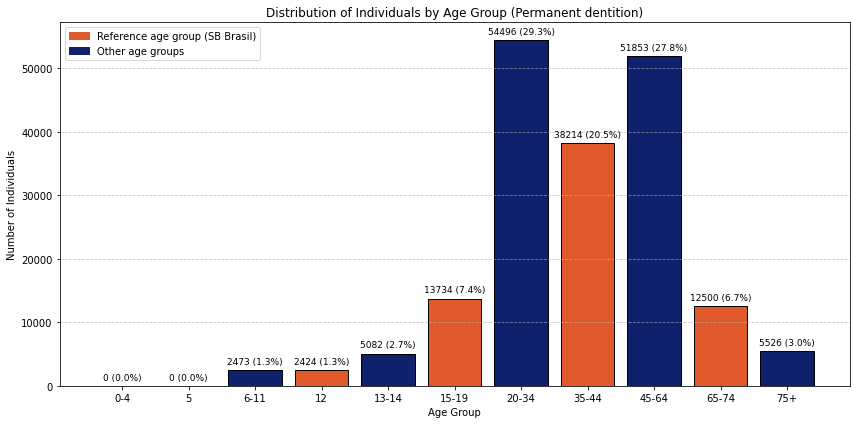

In [38]:
faixas = df_perm['grupo_etario'].value_counts().sort_index()

# Resetar índice para facilitar a manipulação
faixas_reset = faixas.reset_index()

# Calcular frequência relativa (%)
total = faixas_reset['count'].sum()
faixas_reset['percentual'] = (faixas_reset['count'] / total * 100).round(1)

# Faixas de referência (para destacar em laranja vibrante)
faixas_referencia = ['5', '12', '15-19', '35-44', '65-74']

# Definir cores personalizadas
cores = ['#E0592A' if faixa in faixas_referencia else '#0F206C' for faixa in faixas_reset['grupo_etario']]

# Criar gráfico
plt.figure(figsize=(12, 6))
plt.bar(faixas_reset['grupo_etario'], faixas_reset['count'], color=cores, edgecolor='black')

# Títulos e rótulos
plt.xlabel('Age Group')
plt.ylabel('Number of Individuals')
plt.title('Distribution of Individuals by Age Group (Permanent dentition)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibir valores absolutos e relativos sobre as barras
for i, row in faixas_reset.iterrows():
    plt.text(i, row['count'] + total*0.005, 
             f"{row['count']} ({row['percentual']}%)", 
             ha='center', fontsize=9, color='black')

# Legenda no canto superior esquerdo
referencia_patch = mpatches.Patch(color='#E0592A', label='Reference age group (SB Brasil)')
outras_patch = mpatches.Patch(color='#0F206C', label='Other age groups')
plt.legend(handles=[referencia_patch, outras_patch], loc='upper left')

plt.tight_layout()

# Salvar o gráfico
output_path = '/home/ubuntu/Jack/papiron-classificacao/imagens'
plt.savefig(os.path.join(output_path, 'distribuicao_grupo_etario_cores_personalizadas_perma.png'), dpi=300, bbox_inches='tight')

# Mostrar no notebook
plt.show()


In [39]:
# Frequência absoluta
freq_abs = df_perm['origem'].value_counts()

# Frequência relativa (%)
freq_rel = df_perm['origem'].value_counts(normalize=True) * 100

# Combinar em um DataFrame
tabela_origem = pd.DataFrame({
    'Clinic': freq_abs.index,
    'Absolute Frequency': freq_abs.values,
    'Relative Frequency (%)': freq_rel.values.round(2)
})

tabela_origem['Relative Frequency (%)'] = tabela_origem['Relative Frequency (%)'].map(lambda x: f'{x:.2f}')
tabela_origem

# # Adicionar linha de total
# total_abs = tabela_origem['Absolute Frequency'].sum()
# tabela_origem.loc[len(tabela_origem.index)] = ['Total', total_abs, '100.00']

# # Gerar LaTeX
# latex_code = tabela_origem.to_latex(index=False)

# # Substituir as regras booktabs por \hline
# latex_code = (
#     latex_code.replace(r'\toprule', r'\hline')
#               .replace(r'\midrule', r'\hline')
#               .replace(r'\bottomrule', r'\hline')
# )

# # Adicionar ambiente table
# latex_final = (
#     r'\begin{table}[H]' + '\n'
#     r'\centering' + '\n'
#     r'\caption{Distribution of Exams by Clinic}' + '\n'
#     r'\label{tab:origem}' + '\n' +
#     latex_code +
#     r'\end{table}'
# )

# # Exibir LaTeX final
# print(latex_final)


,Clinic,Absolute Frequency,Relative Frequency (%)
0,Santana,31262,16.78
1,Tatuape,27232,14.62
2,Santo Amaro,25666,13.78
3,Jardins,18927,10.16
4,Vila Mariana,17098,9.18
5,Jd. America,14129,7.58
6,Lapa,12416,6.66
7,Mooca,6654,3.57
8,Penha,6495,3.49
9,Ibirapuera,6204,3.33


In [40]:
df_coords

,origem,lat,lon
0,Alphaville,-23.498981,-46.847832
1,Ibirapuera,-23.581731,-46.660043
2,Ipiranga,-23.589273,-46.606162
3,Jardins,-23.561575,-46.660982
4,Jd. America,-23.570323,-46.679811
5,Lapa,-23.521576,-46.704349
6,Mooca,-23.560681,-46.597192
7,Morumbi,-23.596499,-46.717845
8,Osasco,-23.532486,-46.791680
9,Penha,-23.533495,-46.542669


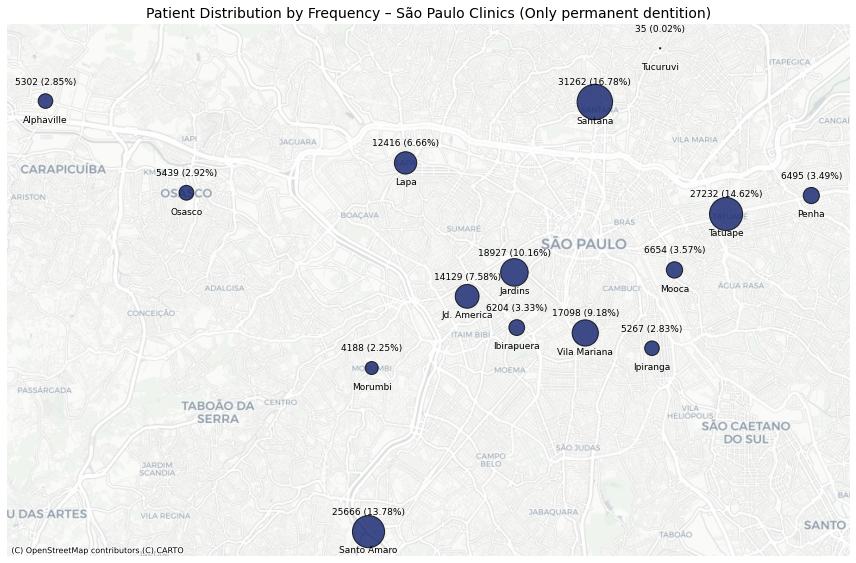

In [41]:
# Caminho de saída
output_path = '/home/ubuntu/Jack/papiron-classificacao/imagens'
os.makedirs(output_path, exist_ok=True)

# Renomear coluna para garantir consistência
tabela_origem = tabela_origem.rename(columns={'Clinic': 'origem'})

# Mesclar as tabelas df_coords e tabela_origem com base na coluna 'origem'
df = df_coords.merge(tabela_origem, on='origem')

# Garantir que a coluna 'Relative Frequency (%)' seja numérica
df['Relative Frequency (%)'] = pd.to_numeric(df['Relative Frequency (%)'], errors='coerce')

# Criar GeoDataFrame com coordenadas
geometry = [Point(xy) for xy in zip(df['lon'], df['lat'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

# Reprojetar para Web Mercator (necessário para contextily)
gdf = gdf.to_crs(epsg=3857)

# Plotar o mapa
fig, ax = plt.subplots(figsize=(12, 12))

# Usar a frequência relativa para o tamanho das bolhas
gdf.plot(ax=ax,
         markersize=gdf["Relative Frequency (%)"] * 75,  # Ajuste visual do tamanho das bolhas
         color='#0F206C', edgecolor='black', alpha=0.8)

# Adicionar o mapa base
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# Título e ajustes no layout
ax.set_title('Patient Distribution by Frequency – São Paulo Clinics (Only permanent dentition)', fontsize=14)
ax.axis('off')
plt.tight_layout()

# Adicionar valores e nomes
for i, row in gdf.iterrows():
    # Colocando o valor absoluto acima da bolha
    ax.text(row.geometry.x, row.geometry.y + 850, f"{row['Absolute Frequency']} ({row['Relative Frequency (%)']}%)" , fontsize=9, ha='center', va='center', color='black')
    
    # Colocando a frequência relativa entre parênteses
    # ax.text(row.geometry.x, row.geometry.y + 250, f"({row['Relative Frequency (%)']}%)", fontsize=9, ha='center', va='center', color='black')
    
    # Colocando o nome do bairro abaixo da bolha
    ax.text(row.geometry.x, row.geometry.y - 850, row['origem'], fontsize=9, ha='center', va='center', color='black')

# Salvar a imagem
filename = 'mapa_bolhas_frequencias_com_nome_perm.png'
plt.savefig(os.path.join(output_path, filename), dpi=300, bbox_inches='tight')

# Exibir no Jupyter
plt.show()


# Quantidade de dentes ausentes por idade

In [42]:
# media_ausentes_idade = df_perm.groupby('idade')['total_dentes_ausentes'].mean()

# media_ausentes_idade.plot(kind='line', figsize=(10, 5))
# plt.xlabel('Age')
# plt.ylabel('Average Number of Missing Teeth')
# plt.title('Average Number of Missing Teeth by Age (Permanent Dentition)')
# plt.grid(True)
# plt.show()

# # plt.savefig('/home/ubuntu/Jack/papiron-classificacao/imagens/missing_teeth_by_age.png')
# # plt.close()

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


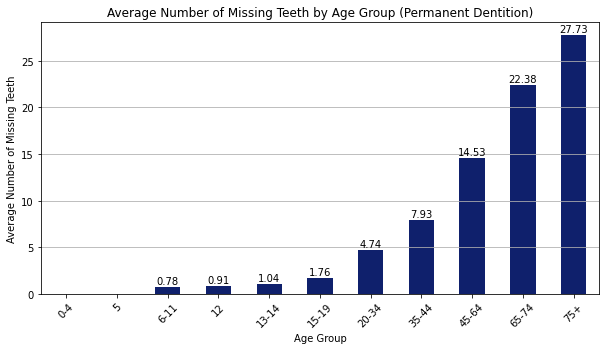

In [43]:
# Calcular a média de dentes ausentes por faixa etária
media_ausentes_faixa = df_perm.groupby('grupo_etario')['total_dentes_ausentes'].mean()

# Criar gráfico de barras
ax = media_ausentes_faixa.plot(kind='bar', figsize=(10, 5), color="#0F206C")

# Adicionar rótulos no gráfico
plt.xlabel('Age Group')
plt.ylabel('Average Number of Missing Teeth')
plt.title('Average Number of Missing Teeth by Age Group (Permanent Dentition)')
plt.xticks(rotation=45)
plt.grid(axis='y')

# Adicionar o número acima de cada barra
for i, v in enumerate(media_ausentes_faixa):
    ax.text(i, v + 0.1, f'{v:.2f}', ha='center', va='bottom', fontsize=10)  # Ajuste a posição conforme necessário

# # Exibir o gráfico
# plt.show()

# Salvar a imagem
plt.savefig('/home/ubuntu/Jack/papiron-classificacao/imagens/missing_teeth_by_age_group.png')
plt.show()
plt.close()


# Quantidade de dentes ausentes por idade e sexo

In [44]:
# # Agrupar por idade e sexo
# media_ausentes = df_perm.groupby(['idade', 'sg_sexo'])['total_dentes_ausentes'].mean().unstack()

# media_ausentes

# # Criar a figura com dois subgráficos (1 linha, 2 colunas)
# fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# # Gráfico para sexo masculino
# media_ausentes['masculino'].plot(ax=axes[0], color='steelblue')
# axes[0].set_title('Average Missing Teeth by Age (Male)')
# axes[0].set_xlabel('Age')
# axes[0].set_ylabel('Average Number of Missing Teeth')
# axes[0].grid(True)

# # Gráfico para sexo feminino
# media_ausentes['feminino'].plot(ax=axes[1], color='salmon')
# axes[1].set_title('Average Missing Teeth by Age (Female)')
# axes[1].set_xlabel('Age')
# axes[1].grid(True)

# # Ajustar o layout
# plt.tight_layout()

# # Salvar
# output_path = '/home/ubuntu/Jack/papiron-classificacao/imagens'
# plt.savefig(os.path.join(output_path, 'missing_teeth_by_age_and_sex.png'), dpi=300, bbox_inches='tight')
# plt.show()

In [45]:
df_perm

,id_exame,dt_exame,sg_sexo,dt_nascimento,cd_exame,se_panoramica,idade,grupo_etario,origem,denticao,total_caries,total_dentes_ausentes
0,5455,2020-01-02,feminino,1990-10-15,alp.025854,1.0,29.0,20-34,Alphaville,denticao permanente,12.0,8.0
2,444,2020-01-04,feminino,1962-08-11,alp.025874,1.0,57.0,45-64,Alphaville,denticao permanente,4.0,30.0
3,523,2020-01-04,feminino,1956-07-17,alp.025876,1.0,63.0,45-64,Alphaville,denticao permanente,8.0,12.0
4,450,2020-01-04,feminino,1988-06-27,alp.025878,1.0,31.0,20-34,Alphaville,denticao permanente,6.0,8.0
5,449,2020-01-04,masculino,1949-01-23,alp.025879,1.0,70.0,65-74,Alphaville,denticao permanente,4.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...
207869,135562,2020-12-30,masculino,2008-05-05,vma.248132,1.0,12.0,12,Vila Mariana,denticao permanente,NaN,NaN
207870,121787,2020-12-30,feminino,1970-12-04,vma.248133,1.0,50.0,45-64,Vila Mariana,denticao permanente,24.0,8.0
207871,122108,2020-12-30,feminino,1978-12-26,vma.248138,1.0,42.0,35-44,Vila Mariana,denticao permanente,0.0,2.0
207872,122709,2020-12-30,feminino,1932-08-22,vma.248140,1.0,88.0,75+,Vila Mariana,denticao permanente,0.0,64.0


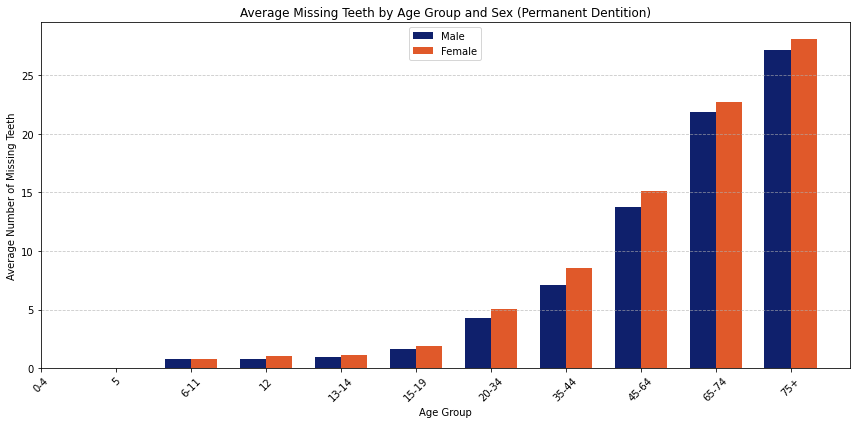

In [46]:
media_ausentes_faixa = df_perm.groupby(['grupo_etario', 'sg_sexo'])['total_dentes_ausentes'].mean().unstack()

# Garantir que os dados estejam ordenados corretamente
media_ausentes_faixa = media_ausentes_faixa.sort_index()

# Dados
labels = media_ausentes_faixa.index.tolist()
x = np.arange(len(labels))
width = 0.35

# Cores personalizadas
cor_masculino = '#0F206C'  # Azul escuro
cor_feminino = '#E0592A'   # Laranja vibrante

# Criar gráfico
fig, ax = plt.subplots(figsize=(12, 6))

# Barras lado a lado
ax.bar(x - width/2, media_ausentes_faixa['masculino'], width, label='Male', color=cor_masculino)
ax.bar(x + width/2, media_ausentes_faixa['feminino'], width, label='Female', color=cor_feminino)

# Rótulos e título
ax.set_xlabel('Age Group')
ax.set_ylabel('Average Number of Missing Teeth')
ax.set_title('Average Missing Teeth by Age Group and Sex (Permanent Dentition)')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Layout e salvar imagem
plt.tight_layout()
output_path = '/home/ubuntu/Jack/papiron-classificacao/imagens'
os.makedirs(output_path, exist_ok=True)
plt.savefig(os.path.join(output_path, 'missing_teeth_by_agegroup_and_sex_groupedbar_customcolors.png'), dpi=300, bbox_inches='tight')

# Exibir
plt.show()


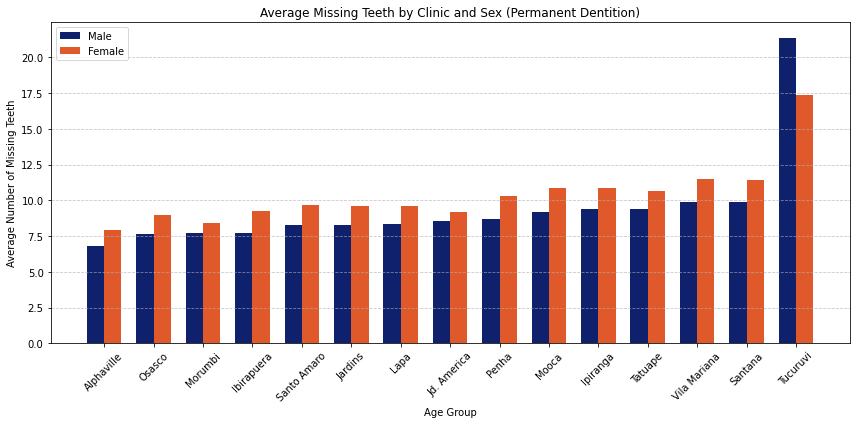

In [47]:
media_ausentes_faixa = df_perm.groupby(['origem','sg_sexo'])['total_dentes_ausentes'].mean().unstack()

# Garantir que os dados estejam ordenados corretamente
media_ausentes_faixa = media_ausentes_faixa.sort_values(by='masculino', ascending=True)

# Dados
labels = media_ausentes_faixa.index.tolist()
x = np.arange(len(labels))
width = 0.35

# Cores personalizadas
cor_masculino = '#0F206C'  # Azul escuro
cor_feminino = '#E0592A'   # Laranja vibrante

# Criar gráfico
fig, ax = plt.subplots(figsize=(12, 6))

# Barras lado a lado
ax.bar(x - width/2, media_ausentes_faixa['masculino'], width, label='Male', color=cor_masculino)
ax.bar(x + width/2, media_ausentes_faixa['feminino'], width, label='Female', color=cor_feminino)

# Rótulos e título
ax.set_xlabel('Age Group')
ax.set_ylabel('Average Number of Missing Teeth')
ax.set_title('Average Missing Teeth by Clinic and Sex (Permanent Dentition)')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Layout e salvar imagem
plt.tight_layout()
output_path = '/home/ubuntu/Jack/papiron-classificacao/imagens'
os.makedirs(output_path, exist_ok=True)
plt.savefig(os.path.join(output_path, 'missing_teeth_by_origem_and_sex_groupedbar_customcolors.png'), dpi=300, bbox_inches='tight')

# Exibir
plt.show()

In [48]:
# # Calcular mediana e quartis por faixa etária e sexo
# summary = df_perm.groupby(['grupo_etario', 'sg_sexo'])['total_dentes_ausentes'].agg(
#     mediana='median',
#     q1=lambda x: x.quantile(0.25),
#     q3=lambda x: x.quantile(0.75)
# ).unstack()

# # Garantir ordem correta das faixas
# summary = summary.sort_index()

# # Preparar dados para plot
# faixas = summary.index.tolist()
# x = np.arange(len(faixas))
# width = 0.35

# # Dados para masculino e feminino
# mediana_m = summary['mediana']['masculino']
# mediana_f = summary['mediana']['feminino']
# err_m = [mediana_m - summary['q1']['masculino'], summary['q3']['masculino'] - mediana_m]
# err_f = [mediana_f - summary['q1']['feminino'], summary['q3']['feminino'] - mediana_f]

# # Cores personalizadas
# cor_masc = '#0F206C'
# cor_fem = '#E0592A'

# # Criar gráfico
# fig, ax = plt.subplots(figsize=(12, 6))

# ax.bar(x - width/2, mediana_f, width, label='Female', color=cor_fem,
#        yerr=err_f, capsize=5)
# ax.bar(x + width/2, mediana_m, width, label='Male', color=cor_masc,
#        yerr=err_m, capsize=5)

# # Rótulos e layout
# ax.set_xlabel('Age Group')
# ax.set_ylabel('Median Number of Missing Teeth')
# ax.set_title('Median Missing Teeth by Age Group and Sex (Permanent Dentition)')
# ax.set_xticks(x)
# ax.set_xticklabels(faixas, rotation=45)
# ax.legend(title='Sex')
# ax.grid(axis='y', linestyle='--', alpha=0.7)

# # Salvar imagem
# plt.tight_layout()
# output_path = '/home/ubuntu/Jack/papiron-classificacao/imagens'
# os.makedirs(output_path, exist_ok=True)
# plt.savefig(os.path.join(output_path, 'missing_teeth_agegroup_sex_median_customcolors.png'), dpi=300, bbox_inches='tight')
# plt.show()


In [49]:
media_ausentes = df_perm.groupby(['origem','grupo_etario','sg_sexo'])['total_dentes_ausentes'].mean().unstack()
media_ausentes

sg_sexo                         feminino  masculino
origem       grupo_etario                          
Alphaville   0-4          NaN        NaN        NaN
             5            NaN        NaN        NaN
             6-11         NaN   0.358974   0.937500
             12           NaN   0.800000   1.130435
             13-14        NaN   0.607143   0.915254
...                        ..        ...        ...
Vila Mariana 20-34        NaN   5.129841   4.301616
             35-44        NaN   8.187429   6.909091
             45-64        NaN  14.689895  13.105991
             65-74        NaN  23.117135  21.967647
             75+          NaN  28.113590  27.195876

[165 rows x 3 columns]

CategoricalIndex(['0-4', '5', '6-11', '12', '13-14', '15-19', '20-34', '35-44',
                  '45-64', '65-74', '75+'],
                 categories=['0-4', '5', '6-11', '12', ..., '35-44', '45-64', '65-74', '75+'], ordered=True, dtype='category', name='grupo_etario')


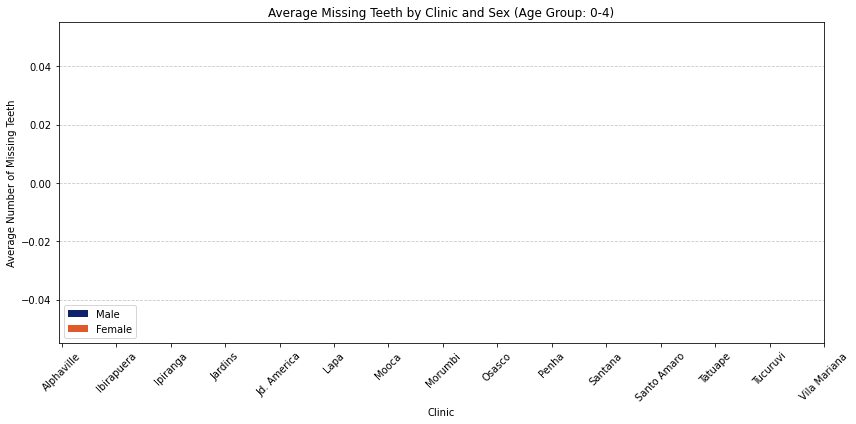

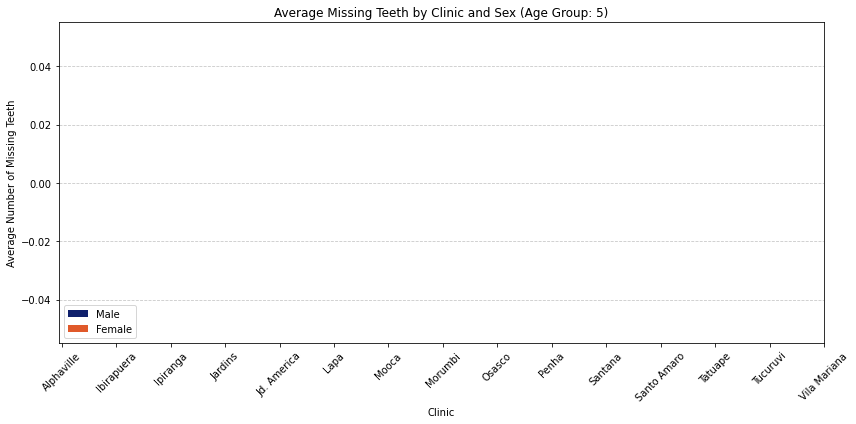

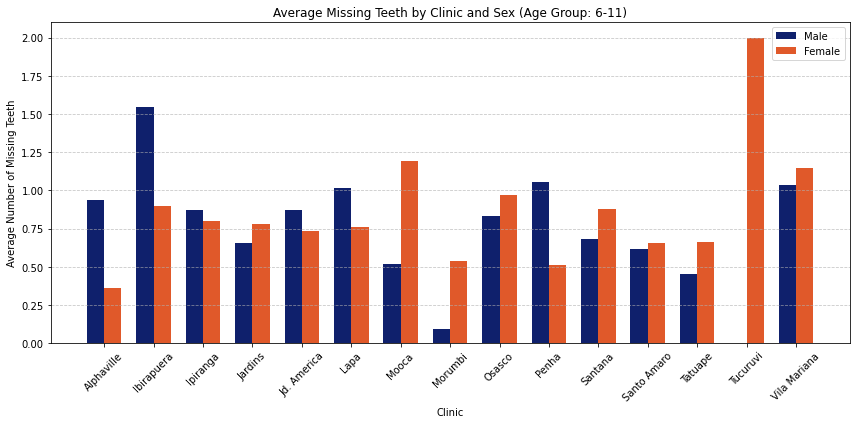

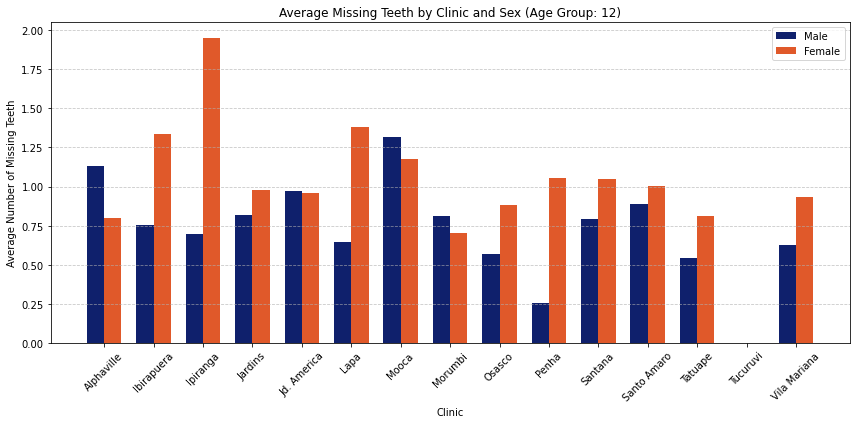

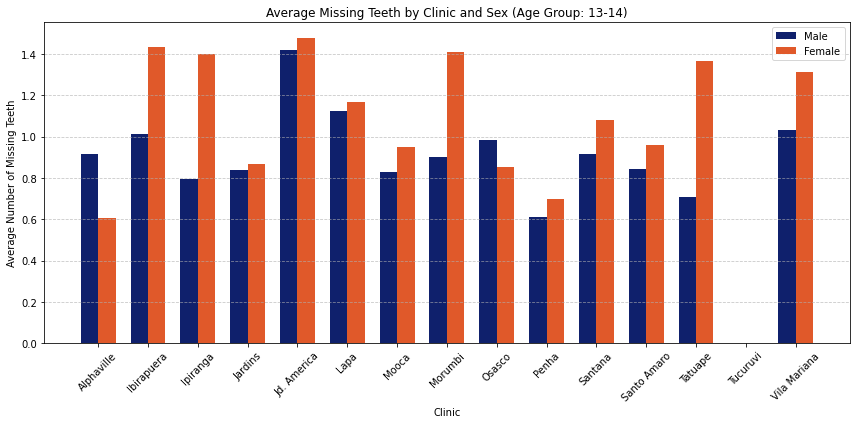

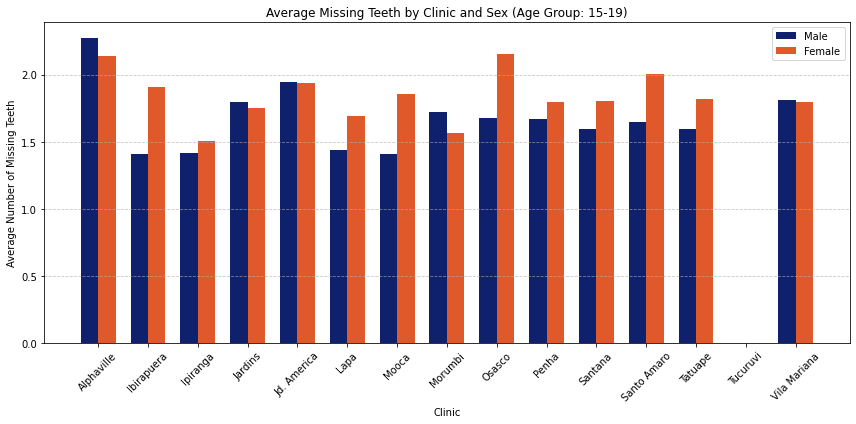

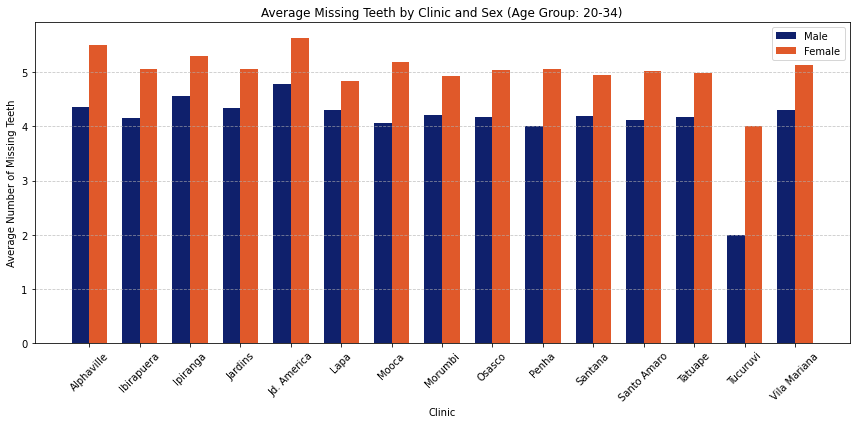

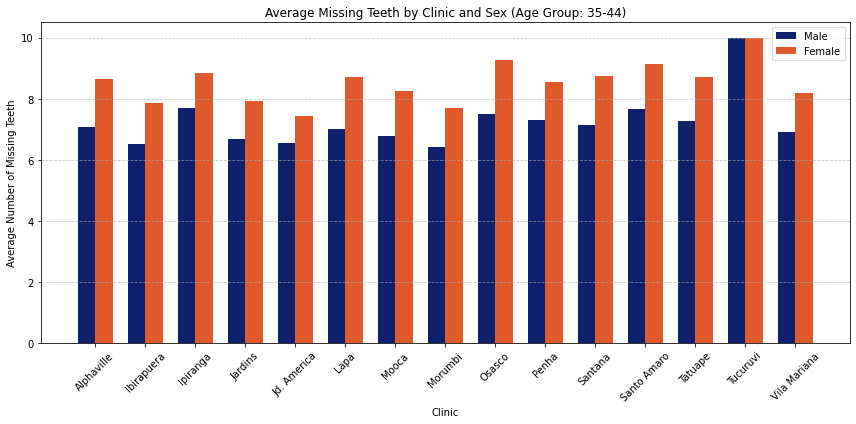

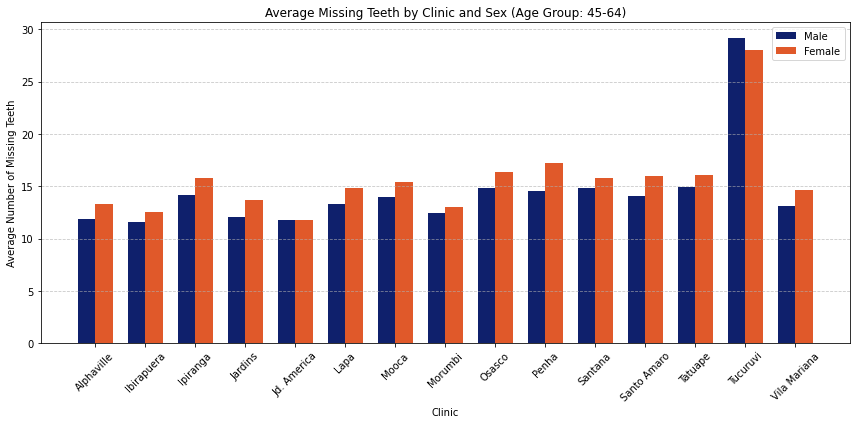

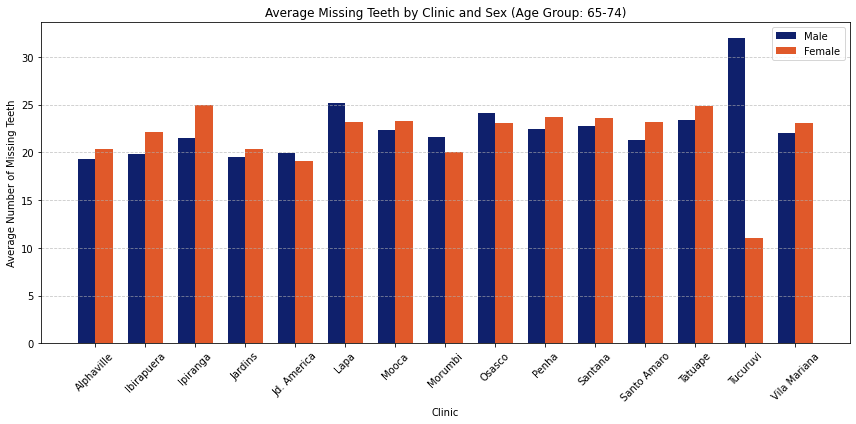

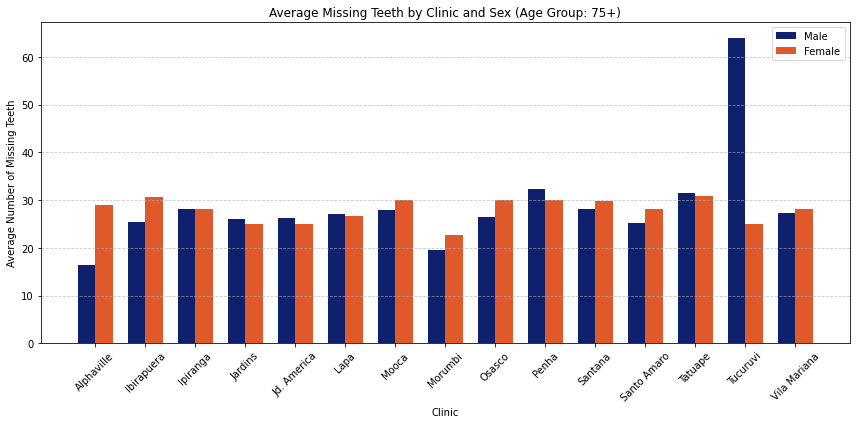

In [50]:
# Vamos gerar gráficos para cada faixa etária
faixas_etarias = media_ausentes.index.get_level_values('grupo_etario').unique()
print(faixas_etarias)

# Caminho de saída
output_path = '/home/ubuntu/Jack/papiron-classificacao/imagens'
os.makedirs(output_path, exist_ok=True)

# Cores personalizadas
cor_masculino = '#0F206C'  # Azul escuro
cor_feminino = '#E0592A'   # Laranja vibrante

# Loop sobre cada faixa etária para gerar os gráficos
for faixa in faixas_etarias:
    # Filtrando os dados para a faixa etária
    media_ausentes_faixa = media_ausentes.xs(faixa, level='grupo_etario')

    # Dados
    labels = media_ausentes_faixa.index.tolist()
    x = np.arange(len(labels))
    width = 0.35

    # Criar gráfico
    fig, ax = plt.subplots(figsize=(12, 6))

    # Barras lado a lado
    ax.bar(x - width/2, media_ausentes_faixa['masculino'], width, label='Male', color=cor_masculino)
    ax.bar(x + width/2, media_ausentes_faixa['feminino'], width, label='Female', color=cor_feminino)

    # Rótulos e título
    ax.set_xlabel('Clinic')
    ax.set_ylabel('Average Number of Missing Teeth')
    ax.set_title(f'Average Missing Teeth by Clinic and Sex (Age Group: {faixa})')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Layout e salvar imagem
    plt.tight_layout()
    plt.savefig(os.path.join(output_path, f'missing_teeth_by_clinic_and_sex_{faixa}.png'), dpi=300, bbox_inches='tight')

    # Exibir gráfico
    plt.show()

# Distribuição da faixa etaria por clinica

In [51]:
# Tabela de frequência absoluta
tabela_faixa_clinica = infos_pan.groupby(['origem', 'grupo_etario']).size().unstack(fill_value=0)
print(tabela_faixa_clinica)

# Frequência relativa (por clínica)
tabela_faixa_clinica_pct = tabela_faixa_clinica.div(tabela_faixa_clinica.sum(axis=1), axis=0) * 100

tabela_faixa_clinica_pct

grupo_etario  0-4    5  6-11   12  13-14  15-19  20-34  35-44  45-64  65-74  \
origem                                                                        
Alphaville     23   56   614   89    145    409   2086   1306   1005    164   
Ibirapuera     30   76   846  106    208    454   1946   1280   1530    408   
Ipiranga       27   41   552   85    139    337   1525   1123   1514    360   
Jardins        66  126  1462  231    414   1104   6649   3518   4754   1468   
Jd. America   125  193  2045  321    531   1111   3636   2970   3708   1083   
Lapa           85  114  1489  219    356   1022   3757   2701   3401    653   
Mooca          32   60   716  114    212    474   1711   1401   1992    472   
Morumbi        18   46   637   96    160    381   1169    966   1063    228   
Osasco         25   51   524  114    188    436   1982   1288   1212    151   
Penha          37   33   606  104    181    489   1940   1489   1879    291   
Santana       138  187  2418  440    727   2222   80

grupo_etario,0-4,5,6-11,12,13-14,15-19,20-34,35-44,45-64,65-74,75+
origem,,,,,,,,,,,
Alphaville,0.387401,0.943237,10.341924,1.499074,2.442311,6.889001,35.135590,21.997642,16.927741,2.762338,0.673741
Ibirapuera,0.423012,1.071630,11.928934,1.494642,2.932882,6.401579,27.439368,18.048505,21.573604,5.752961,2.932882
Ipiranga,0.460908,0.699898,9.423011,1.451007,2.372823,5.752817,26.032776,19.170365,25.844998,6.145442,2.645954
Jardins,0.321684,0.614125,7.125798,1.125896,2.017839,5.380904,32.407272,17.146756,23.171029,7.155042,3.533655
Jd. America,0.763639,1.179058,12.493127,1.961024,3.243937,6.787220,22.212719,18.144053,22.652575,6.616165,3.946484
Lapa,0.605456,0.812024,10.606169,1.559940,2.535793,7.279721,26.761165,19.239262,24.225372,4.651328,1.723769
Mooca,0.432082,0.810154,9.667837,1.539292,2.862544,6.400216,23.102890,18.917094,26.897110,6.373211,2.997570
Morumbi,0.370523,0.946892,13.112392,1.976122,3.293536,7.842734,24.063401,19.884726,21.881433,4.693289,1.934953
Osasco,0.415489,0.847598,8.708659,1.894632,3.124481,7.246136,32.940003,21.406016,20.142928,2.509556,0.764501


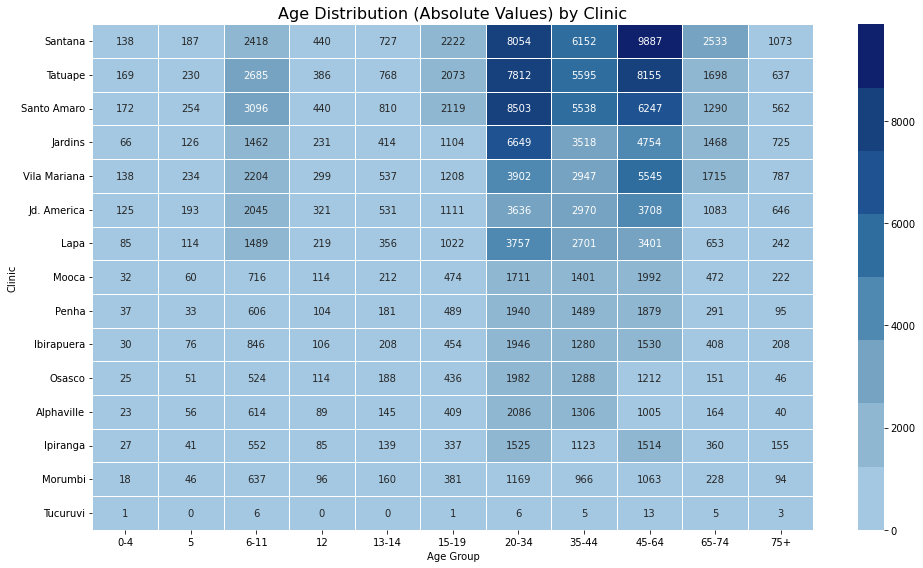

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors

# Definindo a paleta de azuis (do mais claro para o mais escuro)
blue_palette = ["#A4C8E1", "#8FB7D1", "#76A3C1", "#4F89B1", "#2F6D9F", "#1F5290", "#17417D", "#0F206C"]

# Supondo que 'tabela_faixa_clinica' já esteja carregada com os dados
# Adicionar uma coluna de soma total para cada clínica
tabela_faixa_clinica['soma'] = tabela_faixa_clinica.sum(axis=1)

# Ordenar a tabela pela soma de exames, do maior para o menor
tabela_faixa_clinica_sorted = tabela_faixa_clinica.sort_values(by='soma', ascending=False)

# Criar gráfico de calor
plt.figure(figsize=(14, 8))

# Alterar o cmap para a paleta de azul definida anteriormente
sns.heatmap(tabela_faixa_clinica_sorted.drop(columns='soma'), cmap=mcolors.ListedColormap(blue_palette), 
            linewidths=0.5, annot=True, fmt='g')  # 'g' formatação para valores absolutos inteiros

# Títulos e rótulos
plt.title('Age Distribution (Absolute Values) by Clinic', fontsize=16)
plt.xlabel('Age Group')
plt.ylabel('Clinic')

# Ajustar layout
plt.tight_layout()

# Salvar imagem
output_path = '/home/ubuntu/Jack/papiron-classificacao/imagens'
plt.savefig(os.path.join(output_path, 'age_distribution_by_clinic_heatmap_sorted_absolute_values.png'), dpi=300, bbox_inches='tight')

# Exibir
plt.show()

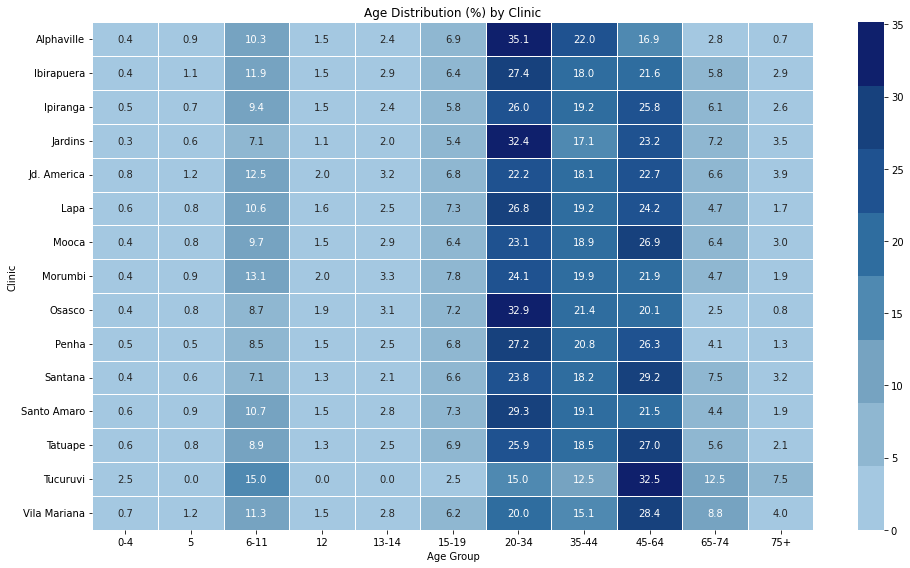

In [53]:
plt.figure(figsize=(14, 8))
blue_palette = ["#A4C8E1", "#8FB7D1", "#76A3C1", "#4F89B1", "#2F6D9F", "#1F5290", "#17417D", "#0F206C"]

sns.heatmap(tabela_faixa_clinica_pct, cmap=blue_palette, linewidths=0.5, annot=True, fmt='.1f')

plt.title('Age Distribution (%) by Clinic')
plt.xlabel('Age Group')
plt.ylabel('Clinic')
plt.tight_layout()

# Salvar imagem
output_path = '/home/ubuntu/Jack/papiron-classificacao/imagens'
plt.savefig(os.path.join(output_path, 'age_distribution_by_clinic_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

In [54]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# import os

# # 1. Definir faixas etárias de crianças e idosos
# faixas_criancas = ['0-4', '5', '6-11', '12', '13-14']
# faixas_idosos = ['65-74', '75+']

# # 2. Criar colunas auxiliares para somar as proporções
# tabela_faixa_clinica_pct['soma_criancas'] = tabela_faixa_clinica_pct[faixas_criancas].sum(axis=1)
# tabela_faixa_clinica_pct['soma_idosos'] = tabela_faixa_clinica_pct[faixas_idosos].sum(axis=1)

# # 3. Ordenar por mais crianças (e menos idosos como critério secundário, opcional)
# df_sorted = tabela_faixa_clinica_pct.sort_values(by=['soma_criancas', 'soma_idosos'], ascending=[False, True])

# # 4. Remover colunas auxiliares antes do gráfico
# df_plot = df_sorted.drop(columns=['soma_criancas', 'soma_idosos'])

# # 5. Criar heatmap
# plt.figure(figsize=(14, 8))
# sns.heatmap(df_plot, cmap='YlOrBr', linewidths=0.5, annot=True, fmt='.1f')

# plt.title('Age Distribution (%) by Clinic (Ordered by Pediatric to Elderly)')
# plt.xlabel('Age Group')
# plt.ylabel('Clinic')
# plt.tight_layout()

# # 6. Salvar imagem
# output_path = '/home/ubuntu/Jack/papiron-classificacao/imagens'
# os.makedirs(output_path, exist_ok=True)
# plt.savefig(os.path.join(output_path, 'age_distribution_by_clinic_heatmap_ordered.png'), dpi=300, bbox_inches='tight')
# plt.show()


## Por mapas

In [55]:
# # Lista dos bairros
# bairros = [
#     'Alphaville', 'Ibirapuera', 'Ipiranga', 'Jardins', 'Jd. America',
#     'Lapa', 'Mooca', 'Morumbi', 'Osasco', 'Penha',
#     'Santana', 'Santo Amaro', 'Tatuape', 'Tucuruvi', 'Vila Mariana'
# ]

# # Criar DataFrame base
# df_coords = pd.DataFrame({'bairro': bairros})
# geolocator = Nominatim(user_agent="mapa_papaiz")

# def get_coords(bairro):
#     try:
#         # Agora estamos buscando apenas pelo bairro, em São Paulo
#         location = geolocator.geocode(f"{bairro}, São Paulo, SP, Brasil")
#         if location:
#             return location.latitude, location.longitude
#         else:
#             return None, None
#     except:
#         return None, None

# # Buscar coordenadas
# latitudes, longitudes = [], []
# for bairro in df_coords['bairro']:
#     lat, lon = get_coords(bairro)
#     latitudes.append(lat)
#     longitudes.append(lon)
#     time.sleep(1)  # Respeitar os limites da API

# # Adicionar ao DataFrame
# df_coords['lat'] = latitudes
# df_coords['lon'] = longitudes

# # Visualizar coordenadas
# print(df_coords)

# # Salvar coordenadas em CSV
# df_coords.to_csv('coordenadas_bairros.csv', index=False)


In [56]:
# geolocator = Nominatim(user_agent="mapa_papaiz")

# location = geolocator.geocode("Cerqueira Cesar, São Paulo, SP, Brasil")
# print(location.latitude, location.longitude)

In [57]:
# Atualizar no DataFrame mantendo o nome "Jardins"
# df_coords.loc[df_coords['bairro'] == 'Jardins', 'lat'] = location.latitude
# df_coords.loc[df_coords['bairro'] == 'Jardins', 'lon'] = location.longitude

# df_coords.to_csv('coordenadas_bairros.csv', index=False)

In [58]:
# # Caminho de saída
# output_path = '/home/ubuntu/Jack/papiron-classificacao/imagens'
# os.makedirs(output_path, exist_ok=True)

# # Renomear coluna para garantir consistência
# df_coords = df_coords.rename(columns={'bairro': 'origem'})

# # Corrigir índice
# tabela_faixa_clinica_pct.index.name = 'origem'

# # Juntar coordenadas com tabela de frequências
# df = df_coords.merge(tabela_faixa_clinica_pct.reset_index(), on='origem')

# # Criar GeoDataFrame com geometria
# geometry = [Point(xy) for xy in zip(df['lon'], df['lat'])]
# gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

# # Reprojetar para Web Mercator (necessário para contextily)
# gdf = gdf.to_crs(epsg=3857)

# # Lista de faixas etárias
# faixas_etarias = ['0-4', '5', '6-11', '12', '13-14', '15-19',
#                   '20-34', '35-44', '45-64', '65-74', '75+']

# # Gerar mapa para cada faixa
# for faixa in faixas_etarias:
#     fig, ax = plt.subplots(figsize=(10, 10))

#     # Plotar pontos dimensionados
#     gdf.plot(ax=ax,
#              markersize=gdf[faixa] * 10,  # Escala visual
#              color='#E0592A', edgecolor='black', alpha=0.8)

#     # Adicionar mapa base
#     ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

#     # Título e layout
#     ax.set_title(f'Frequency of Patients in Age Group {faixa} – São Paulo', fontsize=14)
#     ax.axis('off')
#     plt.tight_layout()

#     # Salvar imagem
#     filename = f'mapa_faixa_{faixa.replace("+", "plus").replace("-", "_")}.png'
#     plt.savefig(os.path.join(output_path, filename), dpi=300, bbox_inches='tight')

#     # Exibir no Jupyter
#     plt.show()


In [59]:
# import geopandas as gpd
# import matplotlib.pyplot as plt
# import contextily as ctx
# import numpy as np
# from shapely.geometry import Point
# import os

# # Criar pasta de saída
# output_path = '/home/ubuntu/Jack/papiron-classificacao/imagens'
# os.makedirs(output_path, exist_ok=True)

# # Faixas etárias e cores
# age_groups = ['0-4', '5', '6-11', '12', '13-14', '15-19',
#               '20-34', '35-44', '45-64', '65-74', '75+']

# colors = {
#     '0-4': '#1f77b4', '5': '#ff7f0e', '6-11': '#2ca02c', '12': '#d62728',
#     '13-14': '#9467bd', '15-19': '#8c564b', '20-34': '#e377c2',
#     '35-44': '#7f7f7f', '45-64': '#bcbd22', '65-74': '#17becf', '75+': '#aec7e8'
# }

# # Parâmetros do círculo de deslocamento
# radius = 1000  # em metros (projeção EPSG:3857)
# n = len(age_groups)
# angles = np.linspace(0, 2*np.pi, n, endpoint=False)

# # Lista para armazenar bolhas deslocadas
# bubbles = []

# # Criar bolhas deslocadas
# for idx, row in gdf.iterrows():
#     x0, y0 = row.geometry.x, row.geometry.y
#     for i, group in enumerate(age_groups):
#         freq = row[group]
#         if freq > 0:
#             angle = angles[i]
#             x = x0 + radius * np.cos(angle)
#             y = y0 + radius * np.sin(angle)
#             bubbles.append({
#                 'origem': row['origem'],
#                 'faixa_etaria': group,
#                 'freq': freq,
#                 'geometry': Point(x, y),
#                 'cor': colors[group]
#             })

# # Criar GeoDataFrame com bolhas deslocadas
# bubbles_gdf = gpd.GeoDataFrame(bubbles, crs="EPSG:3857")

# # Plotar
# fig, ax = plt.subplots(figsize=(12, 12))
# bubbles_gdf.plot(ax=ax,
#                  markersize=bubbles_gdf['freq'] * 10,
#                  color=bubbles_gdf['cor'],
#                  edgecolor='black',
#                  alpha=0.7)

# # Adicionar mapa base
# ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

# # Layout
# ax.set_title('Distribution by Age Group with Offset – Papaiz Clinics', fontsize=14)
# ax.axis('off')

# # Legenda manual (em inglês)
# for group, color in colors.items():
#     ax.scatter([], [], c=color, label=group, s=50, edgecolor='black')
# ax.legend(title='Age Group', loc='lower left', bbox_to_anchor=(1.01, 0.5))

# # Salvar e exibir
# plt.tight_layout()
# plt.savefig(os.path.join(output_path, 'map_bubbles_offset_age_groups.png'), dpi=300, bbox_inches='tight')
# plt.show()


In [60]:
# # Criar pasta de saída
# output_path = '/home/ubuntu/Jack/papiron-classificacao/imagens'
# os.makedirs(output_path, exist_ok=True)

# # Faixas etárias e cores
# age_groups = ['0-4', '5', '6-11', '12', '13-14', '15-19',
#               '20-34', '35-44', '45-64', '65-74', '75+']

# colors = {
#     '0-4': '#1f77b4', '5': '#ff7f0e', '6-11': '#2ca02c', '12': '#d62728',
#     '13-14': '#9467bd', '15-19': '#8c564b', '20-34': '#e377c2',
#     '35-44': '#7f7f7f', '45-64': '#bcbd22', '65-74': '#17becf', '75+': '#aec7e8'
# }

# # Parâmetros do círculo de deslocamento
# radius = 1000  # em metros (projeção EPSG:3857)
# n = len(age_groups)
# angles = np.linspace(0, 2*np.pi, n, endpoint=False)

# # Lista para armazenar bolhas deslocadas
# bubbles = []

# # Criar bolhas deslocadas
# for idx, row in gdf.iterrows():
#     x0, y0 = row.geometry.x, row.geometry.y
#     for i, group in enumerate(age_groups):
#         freq = row[group]
#         if freq > 0:
#             angle = angles[i]
#             x = x0 + radius * np.cos(angle)
#             y = y0 + radius * np.sin(angle)
#             bubbles.append({
#                 'origem': row['origem'],
#                 'age_group': group,
#                 'freq': freq,
#                 'geometry': Point(x, y),
#                 'color': colors[group]
#             })

# # Criar GeoDataFrame com bolhas deslocadas
# bubbles_gdf = gpd.GeoDataFrame(bubbles, crs="EPSG:3857")

# # Plotar
# fig, ax = plt.subplots(figsize=(12, 12))
# bubbles_gdf.plot(ax=ax,
#                  markersize=bubbles_gdf['freq'] * 10,
#                  color=bubbles_gdf['color'],
#                  edgecolor='black',
#                  alpha=0.7)

# # Usar um mapa base clean (CartoDB Positron)
# ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# # Layout
# ax.set_title('Age Group Distribution with Offset – Papaiz Clinics', fontsize=14)
# ax.axis('off')

# # Legenda manual (em inglês)
# for group, color in colors.items():
#     ax.scatter([], [], c=color, label=group, s=50, edgecolor='black')
# ax.legend(title='Age Group', loc='lower left', bbox_to_anchor=(1.01, 0.5))

# # Salvar e exibir
# plt.tight_layout()
# plt.savefig(os.path.join(output_path, 'map_bubbles_offset_age_groups_clean.png'), dpi=300, bbox_inches='tight')
# plt.show()


# Distribuição de sexo por clinica

In [61]:
# Tabela de frequência absoluta
tabela_sexo_clinica = infos_pan.groupby(['origem', 'sg_sexo']).size().unstack(fill_value=0)

# Frequência relativa (% por clínica)
tabela_sexo_clinica_pct = tabela_sexo_clinica.div(tabela_sexo_clinica.sum(axis=1), axis=0) * 100

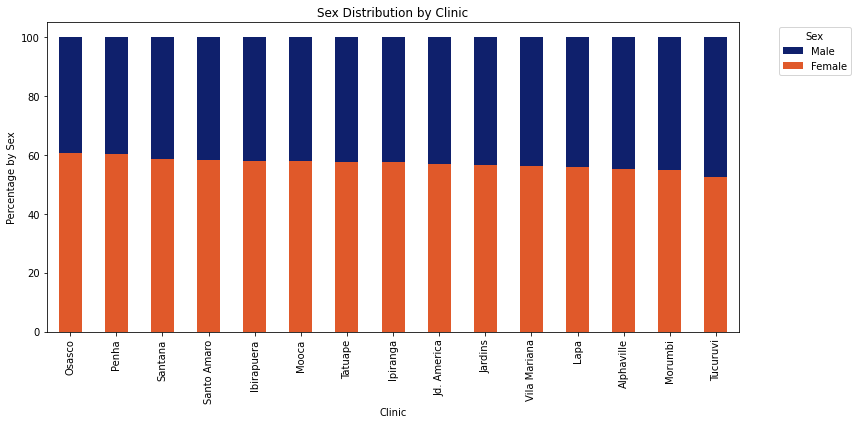

In [62]:
import matplotlib.pyplot as plt

# Ordenar a tabela pelo valor de proporção de homens (assumindo que a proporção de homens está em uma coluna)
# Suponhamos que a coluna que contém a proporção de homens seja 'Male' ou similar
# Para este exemplo, vamos usar 'Male' como nome da coluna

# Ordenar pela proporção de homens (de menor para maior)
tabela_sexo_clinica_pct = tabela_sexo_clinica_pct.sort_values(by='masculino', ascending=True)

# Plotar gráfico de barras empilhadas
ax = tabela_sexo_clinica_pct.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#0F206C', '#E0592A'])

# Definir rótulos e título
plt.xlabel('Clinic')
plt.ylabel('Percentage by Sex')
plt.title('Sex Distribution by Clinic')

# Alterar a legenda para Female e Male
plt.legend(title='Sex', labels=['Male','Female'], bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajuste no layout para melhor apresentação
plt.tight_layout()

# Salvar imagem
output_path = '/home/ubuntu/Jack/papiron-classificacao/imagens'
plt.savefig(os.path.join(output_path, 'sex_distribution_by_clinic.png'), dpi=300, bbox_inches='tight')

# Exibir o gráfico
plt.show()


In [63]:
tabela_sexo_clinica_pct.sort_values(by='masculino', ascending=True)

sg_sexo,,feminino,masculino
origem,,,
Osasco,0.016620,60.594981,39.388400
Penha,0.000000,60.190370,39.809630
Santana,0.000000,58.631595,41.368405
Santo Amaro,0.003445,58.389308,41.607247
Ibirapuera,0.000000,58.065426,41.934574
Mooca,0.000000,58.047529,41.952471
Tatuape,0.000000,57.653095,42.346905
Ipiranga,0.000000,57.586619,42.413381
Jd. America,0.000000,57.031155,42.968845


# Quantidade de dentes cariados por idade e sexo

In [64]:
df_perm

,id_exame,dt_exame,sg_sexo,dt_nascimento,cd_exame,se_panoramica,idade,grupo_etario,origem,denticao,total_caries,total_dentes_ausentes
0,5455,2020-01-02,feminino,1990-10-15,alp.025854,1.0,29.0,20-34,Alphaville,denticao permanente,12.0,8.0
2,444,2020-01-04,feminino,1962-08-11,alp.025874,1.0,57.0,45-64,Alphaville,denticao permanente,4.0,30.0
3,523,2020-01-04,feminino,1956-07-17,alp.025876,1.0,63.0,45-64,Alphaville,denticao permanente,8.0,12.0
4,450,2020-01-04,feminino,1988-06-27,alp.025878,1.0,31.0,20-34,Alphaville,denticao permanente,6.0,8.0
5,449,2020-01-04,masculino,1949-01-23,alp.025879,1.0,70.0,65-74,Alphaville,denticao permanente,4.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...
207869,135562,2020-12-30,masculino,2008-05-05,vma.248132,1.0,12.0,12,Vila Mariana,denticao permanente,NaN,NaN
207870,121787,2020-12-30,feminino,1970-12-04,vma.248133,1.0,50.0,45-64,Vila Mariana,denticao permanente,24.0,8.0
207871,122108,2020-12-30,feminino,1978-12-26,vma.248138,1.0,42.0,35-44,Vila Mariana,denticao permanente,0.0,2.0
207872,122709,2020-12-30,feminino,1932-08-22,vma.248140,1.0,88.0,75+,Vila Mariana,denticao permanente,0.0,64.0


In [69]:
media_cariados_faixa

sg_sexo,,feminino,masculino
grupo_etario,,,
0-4,NaN,NaN,NaN
5,NaN,NaN,NaN
6-11,NaN,3.200000,3.695090
12,NaN,3.247368,3.725159
13-14,10.0,3.418487,4.065559
15-19,NaN,4.498562,4.729920
20-34,14.0,6.492811,6.940154
35-44,NaN,7.744247,7.789427
45-64,NaN,9.141383,9.223710


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


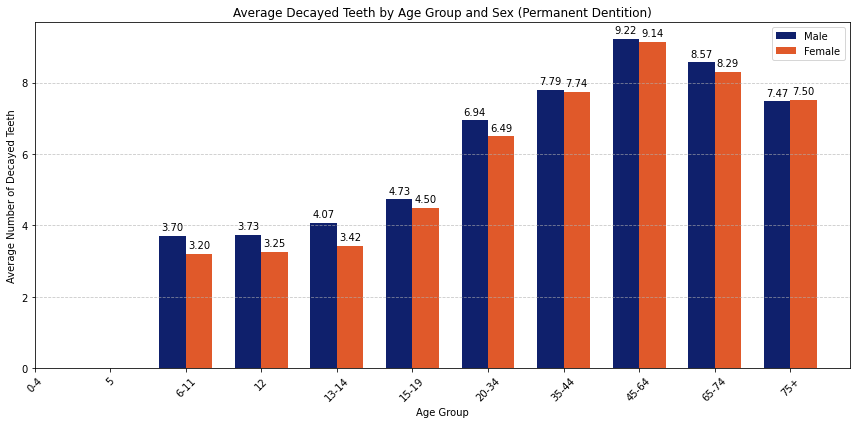

In [71]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Calcular a média de dentes cariados por faixa etária e sexo
media_cariados_faixa = df_perm.groupby(['grupo_etario', 'sg_sexo'])['total_caries'].mean().unstack()

# Garantir que os dados estejam ordenados corretamente
media_cariados_faixa = media_cariados_faixa.sort_index()

# Dados
labels = media_cariados_faixa.index.tolist()
x = np.arange(len(labels))
width = 0.35

# Cores personalizadas
cor_masculino = '#0F206C'  # Azul escuro
cor_feminino = '#E0592A'   # Laranja vibrante

# Criar gráfico
fig, ax = plt.subplots(figsize=(12, 6))

# Barras lado a lado
bars_masculino = ax.bar(x - width/2, media_cariados_faixa['masculino'], width, label='Male', color=cor_masculino)
bars_feminino = ax.bar(x + width/2, media_cariados_faixa['feminino'], width, label='Female', color=cor_feminino)

# Rótulos e título
ax.set_xlabel('Age Group')
ax.set_ylabel('Average Number of Decayed Teeth')
ax.set_title('Average Decayed Teeth by Age Group and Sex (Permanent Dentition)')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar o número acima de cada barra
for bar in bars_masculino:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.1, f'{height:.2f}', ha='center', va='bottom', fontsize=10)

for bar in bars_feminino:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.1, f'{height:.2f}', ha='center', va='bottom', fontsize=10)

# Layout e salvar imagem
plt.tight_layout()
output_path = '/home/ubuntu/Jack/papiron-classificacao/imagens'
os.makedirs(output_path, exist_ok=True)
plt.savefig(os.path.join(output_path, 'caries_by_agegroup_and_sex_groupedbar_customcolors_with_values.png'), dpi=300, bbox_inches='tight')

# Exibir
plt.show()


In [72]:
df_perm.head()

,id_exame,dt_exame,sg_sexo,dt_nascimento,cd_exame,se_panoramica,idade,grupo_etario,origem,denticao,total_caries,total_dentes_ausentes
0,5455,2020-01-02,feminino,1990-10-15,alp.025854,1.0,29.0,20-34,Alphaville,denticao permanente,12.0,8.0
2,444,2020-01-04,feminino,1962-08-11,alp.025874,1.0,57.0,45-64,Alphaville,denticao permanente,4.0,30.0
3,523,2020-01-04,feminino,1956-07-17,alp.025876,1.0,63.0,45-64,Alphaville,denticao permanente,8.0,12.0
4,450,2020-01-04,feminino,1988-06-27,alp.025878,1.0,31.0,20-34,Alphaville,denticao permanente,6.0,8.0
5,449,2020-01-04,masculino,1949-01-23,alp.025879,1.0,70.0,65-74,Alphaville,denticao permanente,4.0,8.0


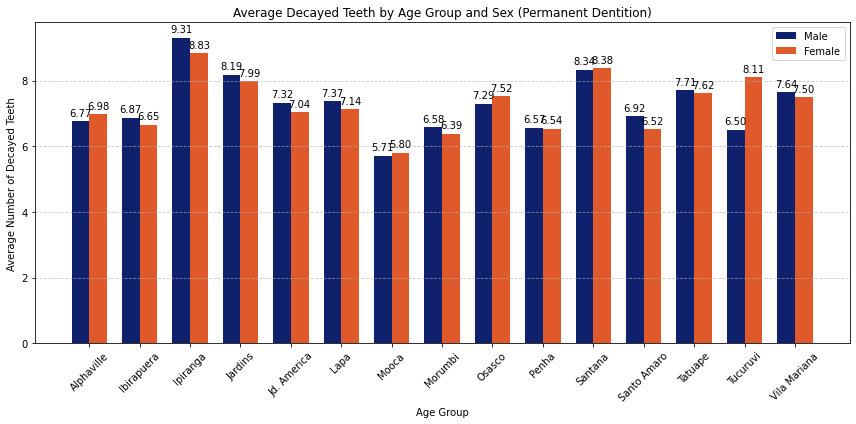

In [73]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Calcular a média de dentes cariados por origem etária e sexo
media_cariados_origem = df_perm.groupby(['origem', 'sg_sexo'])['total_caries'].mean().unstack()

# Garantir que os dados estejam ordenados corretamente
media_cariados_origem = media_cariados_origem.sort_index()

# Dados
labels = media_cariados_origem.index.tolist()
x = np.arange(len(labels))
width = 0.35

# Cores personalizadas
cor_masculino = '#0F206C'  # Azul escuro
cor_feminino = '#E0592A'   # Laranja vibrante

# Criar gráfico
fig, ax = plt.subplots(figsize=(12, 6))

# Barras lado a lado
bars_masculino = ax.bar(x - width/2, media_cariados_origem['masculino'], width, label='Male', color=cor_masculino)
bars_feminino = ax.bar(x + width/2, media_cariados_origem['feminino'], width, label='Female', color=cor_feminino)

# Rótulos e título
ax.set_xlabel('Age Group')
ax.set_ylabel('Average Number of Decayed Teeth')
ax.set_title('Average Decayed Teeth by Age Group and Sex (Permanent Dentition)')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar o número acima de cada barra
for bar in bars_masculino:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.1, f'{height:.2f}', ha='center', va='bottom', fontsize=10)

for bar in bars_feminino:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.1, f'{height:.2f}', ha='center', va='bottom', fontsize=10)

# Layout e salvar imagem
plt.tight_layout()
output_path = '/home/ubuntu/Jack/papiron-classificacao/imagens'
os.makedirs(output_path, exist_ok=True)
plt.savefig(os.path.join(output_path, 'caries_by_origem_and_sex_groupedbar_customcolors_with_values.png'), dpi=300, bbox_inches='tight')

# Exibir
plt.show()

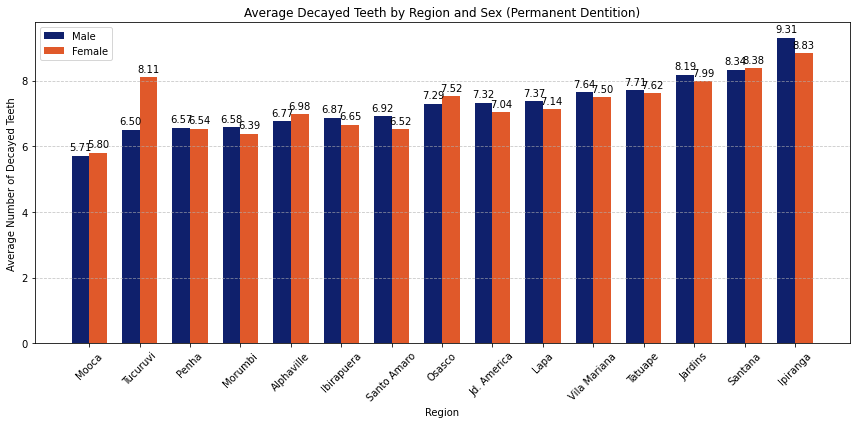

In [75]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Calcular a média de dentes cariados por origem e sexo
media_cariados_origem = df_perm.groupby(['origem', 'sg_sexo'])['total_caries'].mean().unstack()

# Garantir que os dados estejam ordenados pela média masculina
media_cariados_origem = media_cariados_origem.sort_values(by='masculino', ascending=True)  # Ordena pela média masculina

# Dados
labels = media_cariados_origem.index.tolist()
x = np.arange(len(labels))
width = 0.35

# Cores personalizadas
cor_masculino = '#0F206C'  # Azul escuro
cor_feminino = '#E0592A'   # Laranja vibrante

# Criar gráfico
fig, ax = plt.subplots(figsize=(12, 6))

# Barras lado a lado
bars_masculino = ax.bar(x - width/2, media_cariados_origem['masculino'], width, label='Male', color=cor_masculino)
bars_feminino = ax.bar(x + width/2, media_cariados_origem['feminino'], width, label='Female', color=cor_feminino)

# Rótulos e título
ax.set_xlabel('Region')
ax.set_ylabel('Average Number of Decayed Teeth')
ax.set_title('Average Decayed Teeth by Region and Sex (Permanent Dentition)')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar o número acima de cada barra
for bar in bars_masculino:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.1, f'{height:.2f}', ha='center', va='bottom', fontsize=10)

for bar in bars_feminino:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.1, f'{height:.2f}', ha='center', va='bottom', fontsize=10)

# Layout e salvar imagem
plt.tight_layout()
output_path = '/home/ubuntu/Jack/papiron-classificacao/imagens'
os.makedirs(output_path, exist_ok=True)
plt.savefig(os.path.join(output_path, 'caries_by_origem_and_sex_groupedbar_customcolors_with_values_sorted_masculino.png'), dpi=300, bbox_inches='tight')

# Exibir
plt.show()
